# ETS MARL — Thesis Experiments Analysis

This notebook analyzes the thesis experiment sweep against the MAIN/default seed sweep.
It is designed as the cross-config counterpart to `ets_marl - Default RQ Analysis.ipynb` and answers the RQ2 sensitivity questions while reusing MAIN for RQ1/RQ3 decomposition.

**Inputs expected**

- MAIN/default seeds from `configs/sweeps/default_seeds.yaml` (`results/sweeps/default/` or `results/sweeps/default/default/`, depending on where outputs were moved).
- Thesis variants from `configs/sweeps/thesis_experiments.yaml` (`results/sweeps/thesis_experiments/<variant>/`).
- Same paired seeds for MAIN and the structural variants: `1729`, `8191`, `6561`. MAIN may also include seed `5041`; paired comparisons filter to common seeds where needed.

**Variants covered**

- `MAIN` — default LRF/MSR/objective mix.
- `lrf_low_22pct` — lower LRF (`lrf_low`, 2.2%).
- `lrf_high_6pct` — aggressive LRF (`lrf_high`, 6.3% in config; labelled 6% in thesis shorthand).
- `no_market_stability` — `no_msr`, with MSR and unsold-to-MSR disabled.
- `all_financial_objectives` — `all_fin`, all learning agents pure financial.
- `balanced_identical` — `balanced`, identical endowments with 4 financial + 4 ESG agents.
- `high_inflation` — `high_inf`, single-seed probe.

Run all cells after the sweep finishes. If some runs are missing, the notebook will load what exists and mark affected comparisons explicitly.

In [1]:
# Install notebook dependencies if needed.
# Set INSTALL_NOTEBOOK_DEPS = True to force-install the shared notebook requirements.
import subprocess, sys, importlib, re
from pathlib import Path

INSTALL_NOTEBOOK_DEPS = False
_DIST_TO_IMPORT = {
    'pyyaml': 'yaml',
    'scikit-learn': 'sklearn',
    'imbalanced-learn': 'imblearn',
    'opencv-python': 'cv2',
    'pillow': 'PIL',
    'ipython': 'IPython',
}

def _find_requirements():
    req_name = 'requirements-notebooks.txt'
    here = Path.cwd()
    candidates = [here / req_name, here / 'notebooks' / req_name]
    candidates.extend(p / 'notebooks' / req_name for p in here.parents)
    return next((p for p in candidates if p.exists()), None)

def _parse_requirements(req_path):
    dists = []
    for raw in req_path.read_text(encoding='utf-8').splitlines():
        line = raw.strip()
        if not line or line.startswith('#') or line.startswith('-'):
            continue
        line = line.split(';', 1)[0].strip()
        m = re.match(r'^([A-Za-z0-9_.\-]+)', line)
        if m:
            dists.append(m.group(1).lower())
    return dists

def _missing_required(dists):
    missing = []
    for dist in dists:
        mod = _DIST_TO_IMPORT.get(dist, dist.replace('-', '_'))
        try:
            importlib.import_module(mod)
        except ImportError:
            missing.append(dist)
    return missing

req_path = _find_requirements()
if req_path is None:
    raise FileNotFoundError('Could not find notebooks/requirements-notebooks.txt')
missing = _missing_required(_parse_requirements(req_path))
if INSTALL_NOTEBOOK_DEPS or missing:
    if missing:
        print(f'Missing packages: {missing}')
    print(f'Installing notebook dependencies from: {req_path}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(req_path)])
else:
    print('Notebook dependencies available; skipping install.')

Notebook dependencies available; skipping install.


## 1. Setup — Locate Project Root

In [2]:
import os, sys
from pathlib import Path

def _is_project_root(path):
    path = Path(path)
    return (path / 'src').is_dir() and (path / 'configs').is_dir()

env_root = os.environ.get('ETS_MARL_PROJECT_ROOT') or os.environ.get('PROJECT_ROOT')
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
if env_root:
    candidates.append(Path(env_root))
PROJECT_ROOT = next((p.resolve() for p in candidates if _is_project_root(p)), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError(f'Cannot find project root from {Path.cwd()}')
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Working directory: {PROJECT_ROOT}')

Working directory: C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction


## 2. Imports

In [3]:
import copy
import math
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from src.utils.run_data import load_run_csv, log_exists
from src.utils.sweep import load_sweep_spec, expand_dotted_overrides, deep_merge

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 240)
pd.set_option('display.width', 220)

EPS = 1e-9

## 3. Sweep Specs, Variant Labels, and Discovery

In [4]:
MAIN_SPEC = PROJECT_ROOT / 'configs' / 'sweeps' / 'default_seeds.yaml'
EXPERIMENT_SPEC = PROJECT_ROOT / 'configs' / 'sweeps' / 'thesis_experiments.yaml'

# Leave as None to use spec.output_dir. Add paths here if outputs were moved after the run.
OUTPUT_DIR_OVERRIDES = {
    'default_seeds': None,
    'thesis_experiments': None,
}

DISPLAY_NAME = {
    'default': 'MAIN',
    'lrf_low': 'lrf_low_22pct',
    # Fixed thesis shorthand label; later analysis derives the exact LRF
    # percentage from the loaded config rather than from this display string.
    'lrf_high': 'lrf_high_6pct',
    'no_msr': 'no_market_stability',
    'all_fin': 'all_financial_objectives',
    'balanced': 'balanced_identical',
    'high_inf': 'high_inflation',
}
VARIANT_ORDER = ['MAIN', 'lrf_low_22pct', 'lrf_high_6pct', 'no_market_stability',
                 'all_financial_objectives', 'balanced_identical', 'high_inflation']
PAIRED_SEEDS = [1729, 8191, 6561]

SPEC_PATHS = [MAIN_SPEC, EXPERIMENT_SPEC]
for sp in SPEC_PATHS:
    if not sp.exists():
        warnings.warn(f'Sweep spec not found: {sp}')

In [5]:
def _flatten_dict(d, prefix=''):
    out = {}
    if not isinstance(d, dict):
        return out
    for k, v in d.items():
        key = f'{prefix}.{k}' if prefix else str(k)
        if isinstance(v, dict):
            out.update(_flatten_dict(v, key))
        else:
            out[key] = v
    return out

def _variant_display(raw_name):
    return DISPLAY_NAME.get(raw_name, raw_name)

def _as_path_from_spec(spec, spec_path, override=None):
    if override is not None:
        return Path(override).expanduser().resolve()
    p = Path(spec['output_dir'])
    return p if p.is_absolute() else (PROJECT_ROOT / p).resolve()

def _candidate_dirs(output_dir, variant_name, display_name, spec_name):
    dirs = []
    def add(p):
        p = Path(p)
        if p not in dirs:
            dirs.append(p)
    add(output_dir / variant_name)
    add(output_dir / display_name)
    add(output_dir)
    # Common locations used by earlier notebooks / moved sweep outputs.
    add(PROJECT_ROOT / 'results' / 'sweeps' / variant_name)
    add(PROJECT_ROOT / 'results' / 'sweeps' / display_name)
    if display_name == 'MAIN':
        add(PROJECT_ROOT / 'results' / 'sweeps' / 'default')
        add(PROJECT_ROOT / 'results' / 'sweeps' / 'default' / 'default')
    add(PROJECT_ROOT / 'results' / 'sweep' / spec_name / variant_name)
    add(PROJECT_ROOT / 'results' / 'sweep' / spec_name)
    return dirs

def _resolve_run_files(variant_name, display_name, seed, output_dir, spec_name):
    training_names = [
        f'training_log_{variant_name}_s{seed}.csv',
        f'training_log_{display_name}_s{seed}.csv',
        f'training_log_s{seed}.csv',
    ]
    year_names = [
        f'year_log_{variant_name}_s{seed}.csv',
        f'year_log_{display_name}_s{seed}.csv',
        f'year_log_s{seed}.csv',
    ]
    tlog = ylog = None
    for base in _candidate_dirs(output_dir, variant_name, display_name, spec_name):
        if tlog is None:
            for name in training_names:
                cand = base / name
                if log_exists(cand):
                    tlog = cand
                    break
        if ylog is None:
            for name in year_names:
                cand = base / name
                if log_exists(cand):
                    ylog = cand
                    break
        if tlog is not None and ylog is not None:
            break
    return tlog, ylog

# Column subsets keep notebook memory manageable. The shared helper in
# src.utils.run_data is the single source of truth across analysis
# notebooks; unknown columns are silently dropped by load_run_csv.
from src.utils.run_data import default_analysis_columns
EP_COLUMNS, YR_COLUMNS = default_analysis_columns(16)

# Tail-window load size. The notebook only consumes the converged tail
# (TAIL_EPISODES=200 in cell 11 via _tail_ep / _tail_yr); loading just
# the last YR_TAIL_EPISODES episodes per run keeps 16-20 cell sweeps
# in RAM. Set to None below to disable and load full training history.
YR_TAIL_EPISODES = 1000


In [6]:
from IPython.display import display as ipy_display

specs = []
for spec_path in SPEC_PATHS:
    if not spec_path.exists():
        continue
    spec_name = spec_path.stem
    spec = load_sweep_spec(str(spec_path))
    with open(spec['base_config'], encoding='utf-8') as f:
        base_cfg = yaml.safe_load(f)
    output_dir = _as_path_from_spec(spec, spec_path, OUTPUT_DIR_OVERRIDES.get(spec_name))
    specs.append({'name': spec_name, 'path': spec_path, 'spec': spec, 'base_cfg': base_cfg, 'output_dir': output_dir})

load_jobs = []
for s in specs:
    for v in s['spec'].get('variants', []):
        raw_variant = v['name']
        display = _variant_display(raw_variant)
        seeds = v.get('seeds') if v.get('seeds') is not None else s['spec'].get('seeds', [])
        overrides = expand_dotted_overrides(v.get('overrides') or {})
        merged_cfg = deep_merge(copy.deepcopy(s['base_cfg']), overrides)
        for seed in seeds:
            load_jobs.append((s, v, display, seed, merged_cfg, overrides))

runs = {}
discovery = []
for s, v, display, seed, merged_cfg, overrides in tqdm(load_jobs, desc='Discovering/loading runs', unit='run'):
    raw_variant = v['name']
    tlog, ylog = _resolve_run_files(raw_variant, display, seed, s['output_dir'], s['name'])
    row = {
        'sweep': s['name'], 'variant_raw': raw_variant, 'variant': display, 'seed': seed,
        'has_overrides': bool(overrides), 'training_log': str(tlog) if tlog else None,
        'year_log': str(ylog) if ylog else None, 'has_training_log': tlog is not None,
        'has_year_log': ylog is not None, 'found': (tlog is not None) or (ylog is not None),
    }
    discovery.append(row)
    if not row['found']:
        continue
    # Cheap pre-scan: read only the 'episode' column to record total
    # training length before tail-loading the rest. This preserves
    # `len(ep_df)`-style semantics for diagnostics that report total
    # episodes, while keeping peak RAM bounded by YR_TAIL_EPISODES.
    n_total_episodes = 0
    for _meta_path in (tlog, ylog):
        if _meta_path is None:
            continue
        _ep_only = load_run_csv(_meta_path, columns=['episode'])
        if _ep_only is not None and not _ep_only.empty and 'episode' in _ep_only.columns:
            n_total_episodes = int(_ep_only['episode'].max()) + 1
            break
        del _ep_only
    ep_df = load_run_csv(tlog, columns=EP_COLUMNS, tail_episodes=YR_TAIL_EPISODES) if tlog is not None else None
    yr_df = load_run_csv(ylog, columns=YR_COLUMNS, tail_episodes=YR_TAIL_EPISODES) if ylog is not None else None
    if ep_df is None and yr_df is None:
        continue
    if ep_df is None:
        ep_df = pd.DataFrame({'episode': np.sort(yr_df['episode'].dropna().unique())}) if 'episode' in yr_df.columns else pd.DataFrame()
    if yr_df is None:
        yr_df = pd.DataFrame({'episode': ep_df['episode'].values, 'year': np.zeros(len(ep_df), dtype=int)}) if 'episode' in ep_df.columns else pd.DataFrame()
    runs[(display, int(seed))] = {
        'sweep': s['name'], 'variant_raw': raw_variant, 'variant': display, 'seed': int(seed),
        'ep_df': ep_df, 'yr_df': yr_df, 'config': merged_cfg, 'overrides': overrides,
        'training_log': str(tlog) if tlog else None, 'year_log': str(ylog) if ylog else None,
        'n_total_episodes': n_total_episodes if n_total_episodes else len(ep_df),
    }
    # Release pandas/pyarrow buffers between runs so 16-20 cell sweeps don't
    # accumulate a permanent RAM high-water mark.
    import gc; gc.collect()

discovery_df = pd.DataFrame(discovery)
print(f'Discovered {len(discovery_df)} declared runs; loaded {len(runs)} available runs.')
if not discovery_df.empty:
    ipy_display(
        discovery_df.sort_values(['variant', 'seed'])[
            ['variant', 'seed', 'found', 'has_training_log', 'has_year_log', 'training_log', 'year_log']
        ]
    )
if not runs:
    raise RuntimeError('No runs loaded. Check output directories above or set OUTPUT_DIR_OVERRIDES.')

# Free chunked CSV/parquet readers held by pandas/pyarrow before continuing.
import gc; gc.collect()


Discovering/loading runs:   0%|          | 0/20 [00:00<?, ?run/s]

Discovered 20 declared runs; loaded 20 available runs.


,variant,seed,found,has_training_log,has_year_log,training_log,year_log
0,MAIN,1729,True,True,True,C:\Users\danie\Documents\Python_Scripts\Master...,C:\Users\danie\Documents\Python_Scripts\Master...
3,MAIN,5041,True,True,True,C:\Users\danie\Documents\Python_Scripts\Master...,C:\Users\danie\Documents\Python_Scripts\Master...
2,MAIN,6561,True,True,True,C:\Users\danie\Documents\Python_Scripts\Master...,C:\Users\danie\Documents\Python_Scripts\Master...
1,MAIN,8191,True,True,True,C:\Users\danie\Documents\Python_Scripts\Master...,C:\Users\danie\Documents\Python_Scripts\Master...
13,all_financial_objectives,1729,True,True,True,C:\Users\danie\Documents\Python_Scripts\Master...,C:\Users\danie\Documents\Python_Scripts\Master...
15,all_financial_objectives,6561,True,True,True,C:\Users\danie\Documents\Python_Scripts\Master...,C:\Users\danie\Documents\Python_Scripts\Master...
14,all_financial_objectives,8191,True,True,True,C:\Users\danie\Documents\Python_Scripts\Master...,C:\Users\danie\Documents\Python_Scripts\Master...
16,balanced_identical,1729,True,True,True,C:\Users\danie\Documents\Python_Scripts\Master...,C:\Users\danie\Documents\Python_Scripts\Master...
18,balanced_identical,6561,True,True,True,C:\Users\danie\Documents\Python_Scripts\Master...,C:\Users\danie\Documents\Python_Scripts\Master...
17,balanced_identical,8191,True,True,True,C:\Users\danie\Documents\Python_Scripts\Master...,C:\Users\danie\Documents\Python_Scripts\Master...


19

## 4. Shared Helpers

In [7]:
REFERENCE_CONFIG = next(iter(runs.values()))['config']
N_AGENTS = int(REFERENCE_CONFIG.get('companies', {}).get('n_agents', 8))
N_BOTS = int(REFERENCE_CONFIG.get('companies', {}).get('n_bot_agents', 0))
N_TOTAL = N_AGENTS + N_BOTS
N_YEARS = int(REFERENCE_CONFIG.get('simulation', {}).get('n_years', REFERENCE_CONFIG.get('environment', {}).get('n_years', 12)))
TAIL_EPISODES = 1000
ROLL = 50

ARCHETYPES = ['Coal-heavy', 'Gas-dominant', 'Transitioner', 'Green-leader']

def agent_cols(df, prefix, max_idx=N_AGENTS):
    rx = re.compile(rf'^{re.escape(prefix)}_A(\d+)$')
    cols = []
    for c in df.columns:
        m = rx.match(c)
        if m and int(m.group(1)) <= max_idx:
            cols.append((int(m.group(1)), c))
    return [c for _, c in sorted(cols)]

def _agent_archetype(idx0):
    return ARCHETYPES[idx0 // 2] if idx0 // 2 < len(ARCHETYPES) else f'Custom-{idx0 // 2}'

def _reward_weights_for(run):
    return run['config'].get('companies', {}).get('reward_weights', [])

def _agent_weighting(run, idx0):
    weights = _reward_weights_for(run)
    if idx0 < len(weights):
        w_cost, w_green = weights[idx0]
        if float(w_green) <= 1e-8:
            return 'Financial'
        if abs(float(w_cost) - 0.5) < 1e-6 and abs(float(w_green) - 0.5) < 1e-6:
            return 'Balanced ESG'
        return f'w=({w_cost:g},{w_green:g})'
    return 'Financial' if idx0 % 2 == 0 else 'Balanced ESG'

def _tail_ep(run, n=TAIL_EPISODES):
    ep = run['ep_df']
    return ep.tail(min(n, len(ep))) if len(ep) else ep

def _tail_yr(run, n=TAIL_EPISODES):
    yr = run['yr_df']
    ep = _tail_ep(run, n)
    if yr.empty or ep.empty or 'episode' not in yr.columns or 'episode' not in ep.columns:
        return yr.head(0)
    return yr[yr['episode'].isin(ep['episode'].dropna().unique())]

def _yearT(yr):
    if yr.empty or 'year' not in yr.columns:
        return yr.head(0)
    return yr[yr['year'] == yr['year'].max()]

def _safe_mean(x):
    if not isinstance(x, pd.Series):
        x = pd.Series(x)
    x = x.replace([np.inf, -np.inf], np.nan).dropna()
    return float(x.mean()) if len(x) else np.nan

def _safe_std(x):
    if not isinstance(x, pd.Series):
        x = pd.Series(x)
    x = x.replace([np.inf, -np.inf], np.nan).dropna()
    return float(x.std()) if len(x) > 1 else np.nan

def _gini(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan
    if np.all(arr <= 0):
        return 0.0
    arr = np.sort(np.clip(arr, 0, None))
    n = arr.size
    return float((2 * np.arange(1, n + 1) @ arr) / (n * arr.sum()) - (n + 1) / n)

def _rowwise_gini(df, cols):
    if not cols:
        return pd.Series(dtype=float)
    return df[cols].apply(lambda r: _gini(r.values), axis=1)

def _floor_price(run):
    cfg = run['config']
    return float(cfg.get('auction', {}).get('price_min', cfg.get('ets', {}).get('reserve_price', 45.0)))

def _ceiling_price(run):
    return float(run['config'].get('auction', {}).get('price_max', 250.0))

def _variant_color_map():
    palette = sns.color_palette('tab10', n_colors=max(len(VARIANT_ORDER), 3))
    return {name: palette[i % len(palette)] for i, name in enumerate(VARIANT_ORDER)}
VARIANT_COLOR = _variant_color_map()

def paired_runs(variants, seeds=PAIRED_SEEDS):
    return {k: v for k, v in runs.items() if k[0] in variants and k[1] in seeds}

def _ordered_variants_present():
    present = [v for v in VARIANT_ORDER if any(k[0] == v for k in runs)]
    extras = sorted({k[0] for k in runs} - set(present))
    return present + extras

print(f'Reference shape: N_AGENTS={N_AGENTS}, N_BOTS={N_BOTS}, N_YEARS={N_YEARS}, tail={TAIL_EPISODES} episodes')
print('Loaded variants:', _ordered_variants_present())

Reference shape: N_AGENTS=8, N_BOTS=0, N_YEARS=12, tail=1000 episodes
Loaded variants: ['MAIN', 'lrf_low_22pct', 'lrf_high_6pct', 'no_market_stability', 'all_financial_objectives', 'balanced_identical', 'high_inflation']


In [8]:
def summarize_run(run, n=TAIL_EPISODES):
    ep = _tail_ep(run, n)
    yr = _tail_yr(run, n)
    yT = _yearT(yr)
    price_col = 'clearing_price' if 'clearing_price' in yr.columns else None
    floor = _floor_price(run)
    ceil = _ceiling_price(run)

    gf_cols_yr = agent_cols(yr, 'green_frac')
    gf_cols_ep = agent_cols(ep, 'green_frac')
    sf_cols = agent_cols(yr, 'shortfall')
    pen_cols = agent_cols(yr, 'penalty')
    bank_cols = agent_cols(yr, 'bank_end')
    cf_cols = agent_cols(yr, 'carry_forward_end')
    alloc_cols = agent_cols(yr, 'alloc')
    inv_cols_yr = agent_cols(yr, 'invest_cost')
    bid_cols = agent_cols(yr, 'bid_price')
    invest_frac_cols = agent_cols(yr, 'invest_frac_post_clip')
    pre_cols = agent_cols(yr, 'invest_frac_pre_clip')
    post_cols = agent_cols(yr, 'invest_frac_post_clip')

    penalty_values = yr[pen_cols].to_numpy().ravel() if pen_cols else np.array([])
    short_values = yr[sf_cols].to_numpy().ravel() if sf_cols else np.array([])
    if alloc_cols:
        gini_s = _rowwise_gini(yr, alloc_cols)
    elif 'auction_hhi' in yr.columns:
        gini_s = yr['auction_hhi'] / 10000.0
    else:
        gini_s = pd.Series(dtype=float)

    row = {
        'variant': run['variant'], 'seed': run['seed'], 'n_episodes': run.get('n_total_episodes', len(run['ep_df'])),
        'tail_episodes': len(ep),
        'mean_price': _safe_mean(yr[price_col]) if price_col else _safe_mean(ep.get('ep_mean_clearing_price', pd.Series(dtype=float))),
        'final_year_price': _safe_mean(yT[price_col]) if price_col and not yT.empty else _safe_mean(ep.get('clearing_price_last', pd.Series(dtype=float))),
        'within_episode_price_std': _safe_mean(yr.groupby('episode')[price_col].std()) if price_col and 'episode' in yr.columns else _safe_mean(ep.get('price_std', pd.Series(dtype=float))),
        'floor_touch_freq': float((yr[price_col] <= floor * 1.01).mean()) if price_col and len(yr) else np.nan,
        'ceiling_touch_freq': float((yr[price_col] >= ceil * 0.99).mean()) if price_col and len(yr) else np.nan,
        'green_pct_year12': 100.0 * _safe_mean(yT[gf_cols_yr].mean(axis=1)) if gf_cols_yr and not yT.empty else 100.0 * _safe_mean(ep[gf_cols_ep].mean(axis=1)) if gf_cols_ep else np.nan,
        'green_pct_all_years': 100.0 * _safe_mean(yr[gf_cols_yr].mean(axis=1)) if gf_cols_yr else np.nan,
        'investment_total': _safe_mean(yr[inv_cols_yr].sum(axis=1)) if inv_cols_yr else _safe_mean(ep[[c for c in agent_cols(ep, 'invest_cost')]].sum(axis=1)) if agent_cols(ep, 'invest_cost') else np.nan,
        'compliance_rate': float((short_values <= 1e-6).mean()) if short_values.size else np.nan,
        'penalty_frequency': float((penalty_values > 1e-6).mean()) if penalty_values.size else np.nan,
        'penalty_magnitude_positive': float(penalty_values[penalty_values > 1e-6].mean()) if np.any(penalty_values > 1e-6) else 0.0,
        'penalty_total': float(np.nansum(penalty_values) / max(1, yr['episode'].nunique())) if penalty_values.size and 'episode' in yr.columns else np.nan,
        'tnac_year12': _safe_mean(yT['tnac']) if 'tnac' in yT.columns and not yT.empty else _safe_mean(ep.get('yearT_tnac', pd.Series(dtype=float))),
        'tnac_mean': _safe_mean(yr['tnac']) if 'tnac' in yr.columns else np.nan,
        'msr_withhold_events': int((yr.get('msr_withhold_this_year', pd.Series(dtype=float)) > 1e-6).sum()) if len(yr) else 0,
        'msr_release_events': int((yr.get('msr_release_this_year', pd.Series(dtype=float)) > 1e-6).sum()) if len(yr) else 0,
        'msr_withheld_total': float(yr.get('msr_withhold_this_year', pd.Series(dtype=float)).sum()) if len(yr) else np.nan,
        'msr_released_total': float(yr.get('msr_release_this_year', pd.Series(dtype=float)).sum()) if len(yr) else np.nan,
        'unsold_frequency': float((yr.get('auction_unsold', pd.Series(dtype=float)) > 1e-6).mean()) if len(yr) and 'auction_unsold' in yr.columns else np.nan,
        'unsold_total': float(yr.get('auction_unsold', pd.Series(dtype=float)).sum() / max(1, yr['episode'].nunique())) if len(yr) and 'auction_unsold' in yr.columns and 'episode' in yr.columns else np.nan,
        'bank_total_year12': _safe_mean(yT[bank_cols].sum(axis=1)) if bank_cols and not yT.empty else np.nan,
        'bank_total_mean': _safe_mean(yr[bank_cols].sum(axis=1)) if bank_cols else np.nan,
        'carry_forward_mean': _safe_mean(yr[cf_cols].sum(axis=1)) if cf_cols else np.nan,
        'carry_forward_peak': float(np.nanmax(yr[cf_cols].sum(axis=1))) if cf_cols and len(yr) else np.nan,
        'auction_gini': _safe_mean(gini_s),
        'secondary_volume': _safe_mean(ep.get('secondary_volume', pd.Series(dtype=float))),
        'secondary_match_rate': _safe_mean(ep.get('secondary_match_rate', pd.Series(dtype=float))),
        'secondary_buyers_executed': _safe_mean(yr.get('secondary_n_buyers_executed', pd.Series(dtype=float))),
        'secondary_sellers_executed': _safe_mean(yr.get('secondary_n_sellers_executed', pd.Series(dtype=float))),
        'bid_price_agent_var': _safe_mean(yr[bid_cols].var(axis=1)) if bid_cols else np.nan,
        'invest_frac_agent_var': _safe_mean(yr[invest_frac_cols].var(axis=1)) if invest_frac_cols else np.nan,
        'bank_agent_var': _safe_mean(yr[bank_cols].var(axis=1)) if bank_cols else np.nan,
        'budget_gate_clip_freq': float((yr[pre_cols].to_numpy() > yr[post_cols].to_numpy() + 1e-6).mean()) if pre_cols and post_cols and len(pre_cols) == len(post_cols) and len(yr) else np.nan,
        'quality_score': _safe_mean(ep.get('quality_score', pd.Series(dtype=float))),
        'Q_compliance': _safe_mean(ep.get('Q_compliance', pd.Series(dtype=float))),
        'Q_volatility': _safe_mean(ep.get('Q_volatility', pd.Series(dtype=float))),
        'system_reward': _safe_mean(ep[agent_cols(ep, 'reward')].sum(axis=1)) if agent_cols(ep, 'reward') else np.nan,
    }
    return row

summary_df = pd.DataFrame([summarize_run(run) for run in runs.values()])
summary_df['variant'] = pd.Categorical(summary_df['variant'], categories=VARIANT_ORDER, ordered=True)
summary_df = summary_df.sort_values(['variant', 'seed']).reset_index(drop=True)

agg_cols = [c for c in summary_df.columns if c not in {'variant', 'seed'}]
summary_agg = summary_df.groupby('variant', observed=True)[agg_cols].agg(['mean', 'std', 'count'])
print('Per-run converged-window summary:')
display = ipy_display
display(summary_df)
print('Variant-level mean/std/count:')
display(summary_agg)

Per-run converged-window summary:


,variant,seed,n_episodes,tail_episodes,mean_price,final_year_price,within_episode_price_std,floor_touch_freq,ceiling_touch_freq,green_pct_year12,green_pct_all_years,investment_total,compliance_rate,penalty_frequency,penalty_magnitude_positive,penalty_total,tnac_year12,tnac_mean,msr_withhold_events,msr_release_events,msr_withheld_total,msr_released_total,unsold_frequency,unsold_total,bank_total_year12,bank_total_mean,carry_forward_mean,carry_forward_peak,auction_gini,secondary_volume,secondary_match_rate,secondary_buyers_executed,secondary_sellers_executed,bid_price_agent_var,invest_frac_agent_var,bank_agent_var,budget_gate_clip_freq,quality_score,Q_compliance,Q_volatility,system_reward
0,MAIN,1729,120000,1000,66.963310,82.345268,24.691515,0.419750,0.000000,73.470724,69.112539,428.318695,0.875062,0.124938,160.153717,1920.883875,10.924809,17.110023,9488,0,40393.207031,0.000000,0.010333,0.094683,9.691194,17.035357,1.001507,7.506701,0.358308,43.932224,0.921824,1.373750,1.568583,2309.026611,0.000180,3.703675,0.000000,1.712362,0.875062,0.267910,20.078566
1,MAIN,5041,120000,1000,46.519001,48.423588,4.414938,0.955167,0.000000,74.754930,69.998831,426.762238,0.786698,0.213302,210.048172,4301.156000,10.791998,15.644604,8811,1,32821.937500,1.456100,0.245667,4.482898,9.906578,15.587887,2.274683,19.173498,0.316028,30.116215,0.813646,1.050333,1.235417,1714.181030,0.000187,3.905077,0.000000,1.015298,0.786698,0.196200,24.874884
2,MAIN,6561,120000,1000,56.253056,81.394997,19.755203,0.689083,0.000000,77.119780,70.891494,571.575439,0.796875,0.203125,194.529587,3793.327000,14.092499,18.124180,9872,0,44282.257812,0.000000,0.005583,0.042803,12.688789,18.299313,1.996645,8.656900,0.373450,27.110363,0.731078,0.882833,1.052000,2283.851318,0.000177,6.368018,0.000000,1.344589,0.796875,0.235044,12.397699
3,MAIN,8191,120000,1000,47.796135,58.164173,5.435904,0.945833,0.000000,76.509655,70.784312,535.529297,0.852698,0.147302,178.846375,2529.066500,11.706266,13.663610,7694,33,22209.158203,48.051300,0.625750,19.141215,11.092328,13.705705,1.322948,41.689297,0.305214,40.209431,0.923902,1.423500,1.805083,1367.592285,0.000183,4.539381,0.000000,1.331040,0.852699,0.196733,31.475977
4,lrf_low_22pct,1729,120000,1000,51.550648,59.075333,13.453928,0.775833,0.000000,73.961496,69.507128,391.614716,0.915312,0.084687,126.534714,1028.727250,22.212372,20.776672,9951,0,51106.753906,0.000000,0.099750,1.880018,21.622143,21.696255,0.535417,6.916300,0.378755,64.889420,0.948918,2.204000,2.145000,1542.453979,0.000185,5.184589,0.000000,1.630737,0.915313,0.236634,23.293180
5,lrf_low_22pct,6561,120000,1000,45.565392,45.880981,1.668082,0.977917,0.000000,77.448022,70.995313,567.620483,0.913594,0.086406,142.176987,1179.358125,25.338104,21.870255,9994,0,53652.339844,0.000000,0.022667,0.347258,25.170380,23.085522,0.620955,15.593101,0.402065,50.149681,0.947661,1.873500,1.959167,1701.777344,0.000184,10.051917,0.000000,1.716004,0.913594,0.120618,30.440456
6,lrf_low_22pct,8191,120000,1000,45.904827,46.795124,2.683723,0.966167,0.000000,76.558948,70.667756,551.289185,0.932021,0.067979,116.292732,758.926312,24.420315,21.056721,9973,1,51319.078125,1.456100,0.140833,2.307949,24.350962,22.203703,0.399682,5.508700,0.366603,65.783546,0.977646,2.310333,2.328000,1541.574707,0.000184,6.835205,0.000000,1.762699,0.932025,0.130180,34.237522
7,lrf_high_6pct,1729,120000,1000,189.248474,249.776505,68.892838,0.061917,0.436417,73.973340,69.060528,413.524078,0.585990,0.414010,226.406967,8998.545000,5.105099,13.827198,7574,212,27487.664062,308.693176,0.357333,12.197982,2.859297,13.183206,4.649375,24.142300,0.437833,32.883064,0.742340,1.086917,1.197833,333.516968,0.000174,5.741252,0.000000,-0.930481,0.585989,0.268985,-105.518532
8,lrf_high_6pct,6561,120000,1000,146.118057,242.258057,76.444519,0.259250,0.179250,72.124189,68.539113,287.182678,0.742990,0.257010,168.235703,4150.880000,4.294302,13.554935,6902,399,26658.185547,580.983887,0.169083,4.690793,2.491965,12.880333,2.115828,16.197601,0.434757,36.148891,0.887205,1.

Variant-level mean/std/count:


n_episodes            tail_episodes             mean_price                  final_year_price                  within_episode_price_std                  floor_touch_freq                  \
                               mean  std count          mean  std count        mean        std count             mean        std count                     mean        std count             mean       std count   
variant                                                                                                                                                                                                             
MAIN                       120000.0  0.0     4        1000.0  0.0     4   54.382875   9.433815     4        67.582006  16.975406     4                13.574390  10.196788     4         0.752458  0.253769     4   
lrf_low_22pct              120000.0  0.0     3        1000.0  0.0     3   47.673622   3.361889     3        50.583813   7.368063     3                 5.935244   6.531143     3         0.906639  0.113433     3   
lrf_high_6pct              120000.0  0.0     3        1000.0  0.0     3  178.122874  28.142752     3       247.242386   4.316760     3                70.046763   5.905954     3         0.125139  0.116207     3   
no_market_stability        120000.0  0.0     3        1000.0  0.0     3   47.953077   3.143078     3        55.865658  10.030886     3                 6.385721   6.127573     3         0.913389  0.086960     3   
all_financial_objectives   120000.0  0.0     3        1000.0  0.0     3   54.914703   9.746862     3        67.941888  21.802344     3                16.437135  15.232429     3         0.765167  0.181532     3   
balanced_identical         120000.0  0.0     3        1000.0  0.0     3   63.501218  23.154770     3        95.648310  59.951229     3                24.196800  23.412941     3         0.690722  0.310372     3   
high_inflation             120000.0  NaN     1        1000.0  NaN     1   79.493523        NaN     1       160.730865        NaN     1                46.758656        NaN     1         0.533250       NaN     1   

                         ceiling_touch_freq                 green_pct_year12                 green_pct_all_years                 investment_total                   compliance_rate                 penalty_frequency  \
                                       mean       std count             mean       std count                mean       std count             mean         std count            mean       std count              mean   
variant                                                                                                                                                                                                                 
MAIN                               0.000000  0.000000     4        75.463772  1.664425     4           70.196794  0.825143     4       490.546417   74.229089     4        0.827833  0.042815     4          0.172167   
lrf_low_22pct                      0.000000  0.000000     3        75.989489  1.811678     3           70.390066  0.781989     3       503.508128   97.245975     3        0.920309  0.010179     3          0.079691   
lrf_high_6pct                      0.370667  0.168457     3        73.638711  1.378025     3           69.167290  0.687801     3       377.492920   78.741358     3        0.628993  0.099711     3          0.371007   
no_market_stability                0.000000  0.000000     3        75.259747  2.599818     3           70.004918  1.145451     3       456.583079  141.597474     3        0.935007  0.035362     3          0.064993   
all_financial_objectives           0.000000  0.000000     3        74.263918  4.137265     3           69.357649  1.890527     3       409.204488  218.044523     3        0.851115  0.033300     3          0.148885   
balanced_identical                 0.001639  0.002839     3        61.167109  3.077866     3           58.467527  1.466926     3       205.220178  172.079421 

## 5. Cross-Variant Overview (RQ1/RQ2/RQ3 Bridge)

This section establishes the analysis frame:

- **RQ1 credibility:** whether converged-window quality, compliance, and volatility are stable enough to interpret.
- **RQ2 regulatory sensitivity:** whether LRF/MSR variants shift price, TNAC, compliance, and decarbonization beyond seed noise.
- **RQ3 strategy aggregation:** whether objective/endowment variants alter agent-level strategy dispersion and market outcomes.

C:\Users\danie\AppData\Local\Temp\ipykernel_24276\460732173.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='variant', y=metric, order=[v for v in VARIANT_ORDER if v in set(df['variant'].astype(str))],
C:\Users\danie\AppData\Local\Temp\ipykernel_24276\460732173.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='variant', y=metric, order=[v for v in VARIANT_ORDER if v in set(df['variant'].astype(str))],
C:\Users\danie\AppData\Local\Temp\ipykernel_24276\460732173.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplo

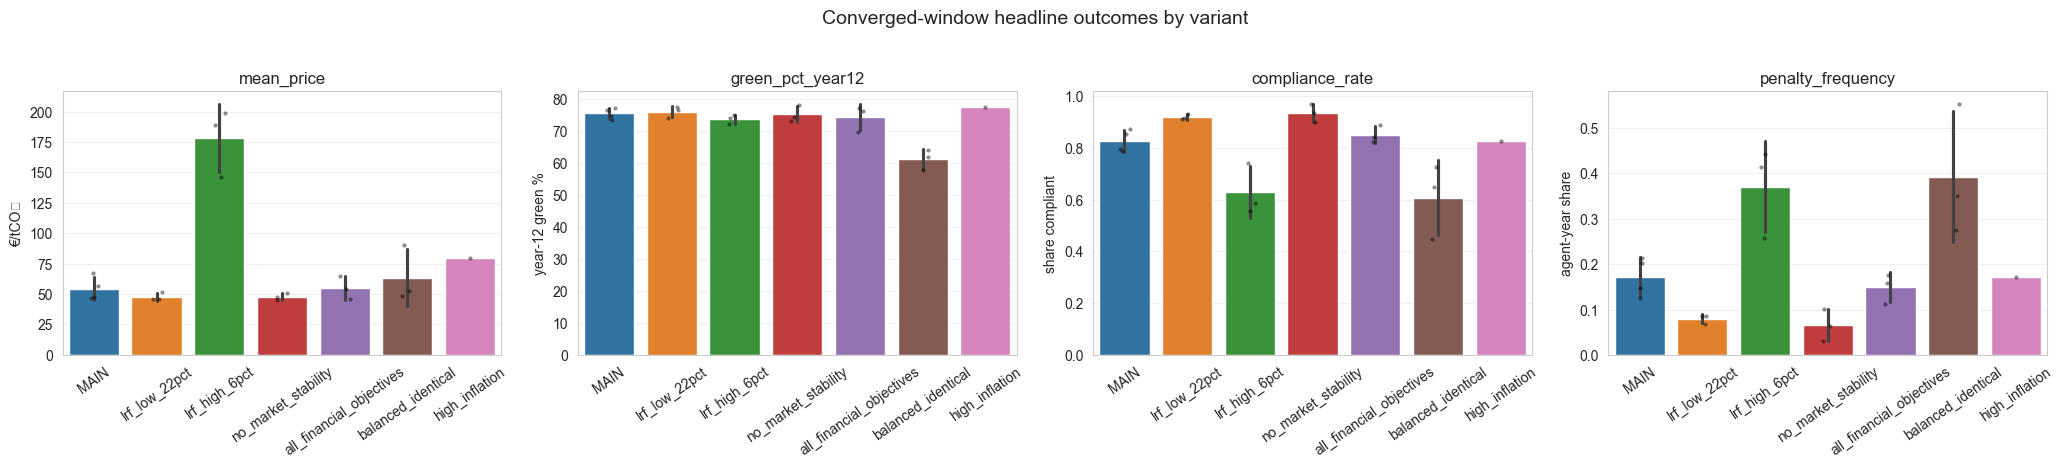

C:\Users\danie\AppData\Local\Temp\ipykernel_24276\460732173.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='variant', y=metric, order=[v for v in VARIANT_ORDER if v in set(df['variant'].astype(str))],
C:\Users\danie\AppData\Local\Temp\ipykernel_24276\460732173.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='variant', y=metric, order=[v for v in VARIANT_ORDER if v in set(df['variant'].astype(str))],
C:\Users\danie\AppData\Local\Temp\ipykernel_24276\460732173.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplo

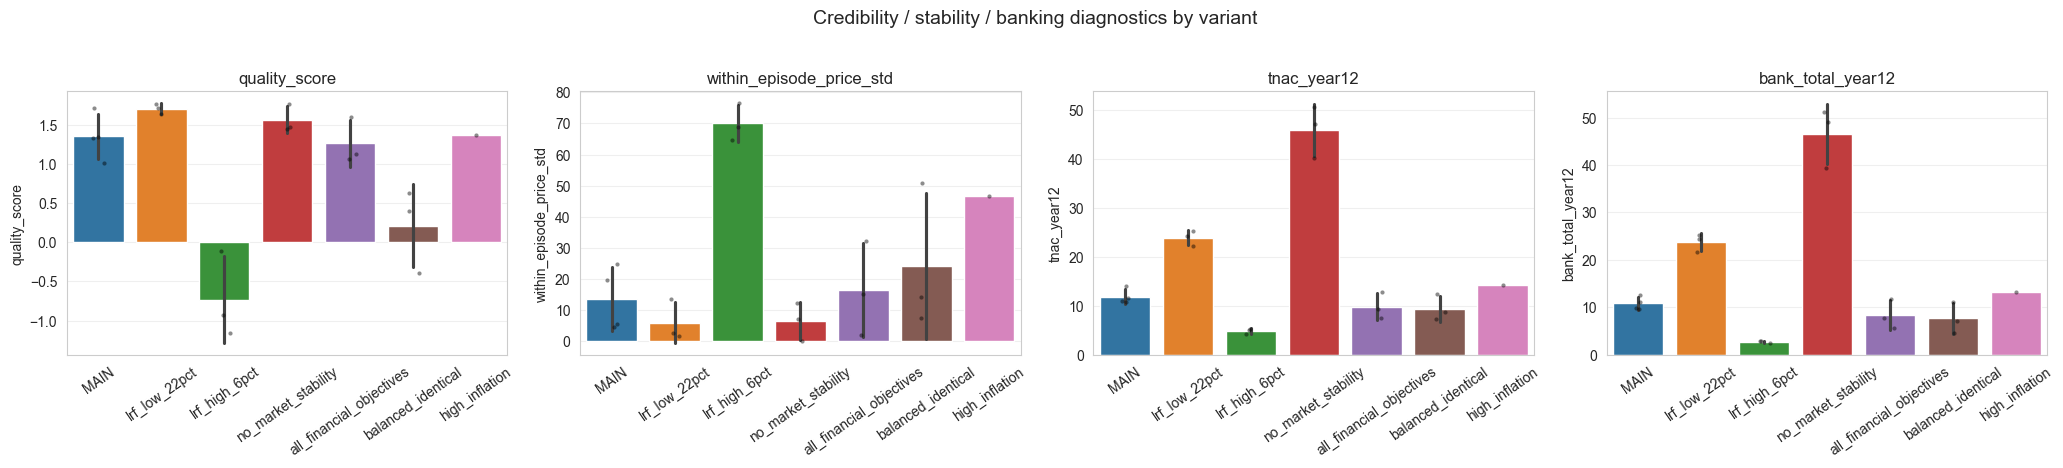

In [9]:
def plot_variant_bars(metrics, title, ylabel_map=None, paired_only=False):
    df = summary_df.copy()
    if paired_only:
        df = df[df['seed'].isin(PAIRED_SEEDS)]
    n = len(metrics)
    fig, axes = plt.subplots(1, n, figsize=(5.2 * n, 4.5), squeeze=False)
    for ax, metric in zip(axes.ravel(), metrics):
        if metric not in df.columns:
            ax.text(0.5, 0.5, f'{metric}\nnot available', ha='center', va='center', transform=ax.transAxes)
            continue
        sns.barplot(data=df, x='variant', y=metric, order=[v for v in VARIANT_ORDER if v in set(df['variant'].astype(str))],
                    errorbar='sd', ax=ax, palette=VARIANT_COLOR)
        sns.stripplot(data=df, x='variant', y=metric, order=[v for v in VARIANT_ORDER if v in set(df['variant'].astype(str))],
                      ax=ax, color='black', alpha=0.45, size=3)
        ax.set_title(metric)
        ax.set_xlabel('')
        ax.set_ylabel((ylabel_map or {}).get(metric, metric))
        ax.tick_params(axis='x', rotation=35)
        ax.grid(True, alpha=0.3, axis='y')
    fig.suptitle(title, fontsize=14, y=1.03)
    plt.tight_layout(); plt.show()

plot_variant_bars(['mean_price', 'green_pct_year12', 'compliance_rate', 'penalty_frequency'],
                  'Converged-window headline outcomes by variant',
                  {'mean_price': '€/tCO₂', 'green_pct_year12': 'year-12 green %', 'compliance_rate': 'share compliant', 'penalty_frequency': 'agent-year share'})
plot_variant_bars(['quality_score', 'within_episode_price_std', 'tnac_year12', 'bank_total_year12'],
                  'Credibility / stability / banking diagnostics by variant')

In [10]:
variant_matrix = []
_seen_variant_seed = set()
for run in runs.values():
    _key = (run['variant'], run['seed'])
    if _key in _seen_variant_seed:
        continue
    _seen_variant_seed.add(_key)
    flat = _flatten_dict(run['overrides'])
    variant_matrix.append({
        'variant': run['variant'], 'raw_variant': run['variant_raw'], 'seed_example': run['seed'],
        'overrides': ', '.join(f'{k}={v}' for k, v in flat.items()) if flat else '(base config)',
    })
variant_matrix_df = pd.DataFrame(variant_matrix).drop_duplicates('variant').sort_values('variant')
display(variant_matrix_df)

,variant,raw_variant,seed_example,overrides
0,MAIN,default,1729,(base config)
13,all_financial_objectives,all_fin,1729,"companies.reward_weights=[[1.0, 0.0], [1.0, 0...."
16,balanced_identical,balanced,1729,"companies.initial_mix=[[0.15, 0.35, 0.25, 0.15..."
19,high_inflation,high_inf,1729,"penalty.inflation_rate=0.04, penalty.inflation..."
7,lrf_high_6pct,lrf_high,1729,ets.lrf_phase2=0.063
4,lrf_low_22pct,lrf_low,1729,ets.lrf_phase2=0.022
10,no_market_stability,no_msr,1729,"ets.msr.enabled=False, ets.unsold_to_msr=False"


## 6. LRF Low (2.2%) vs MAIN

C:\Users\danie\AppData\Local\Temp\ipykernel_24276\2486335180.py:39: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


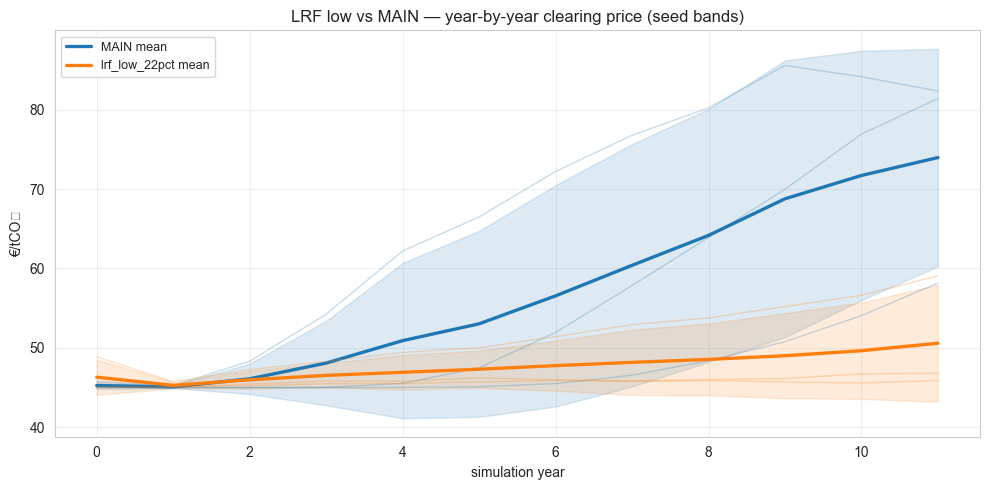

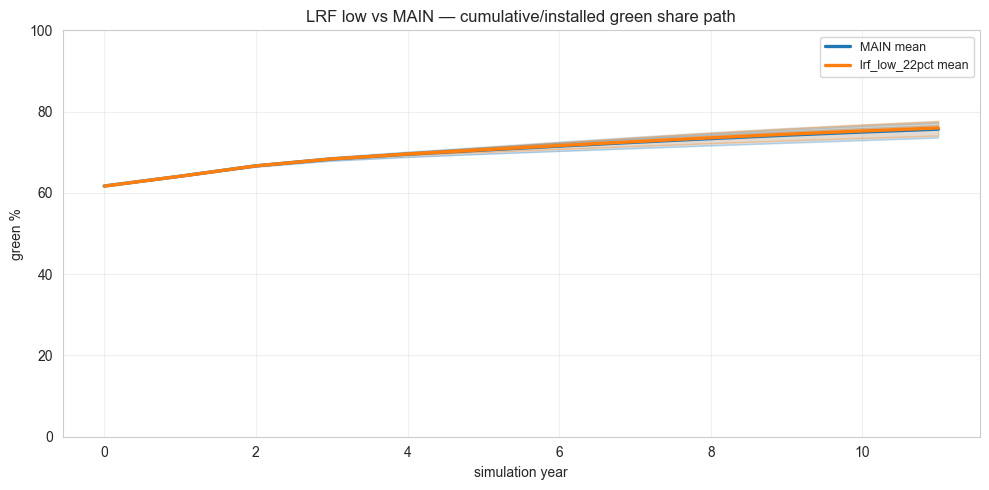

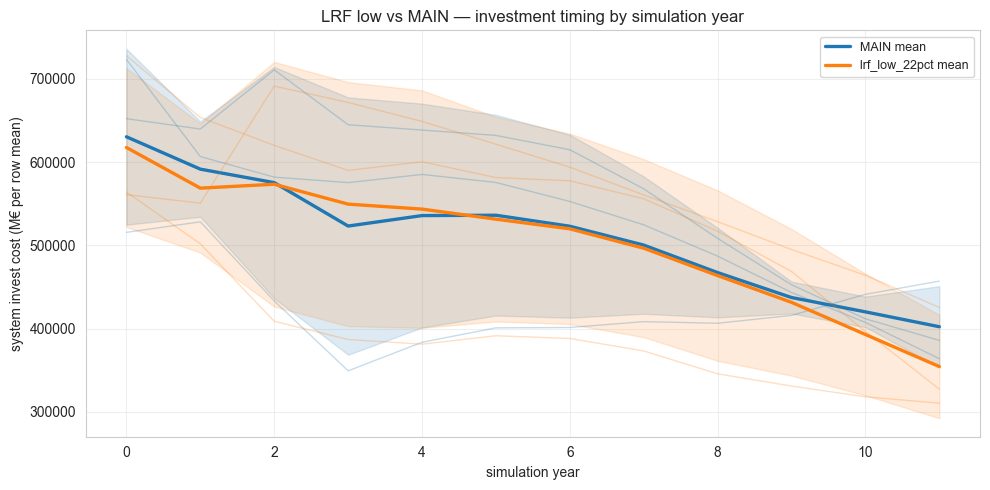

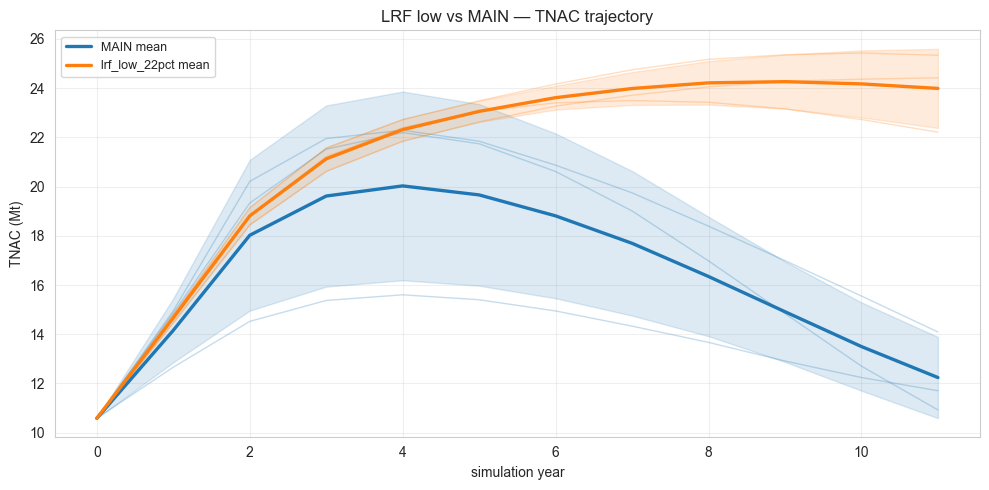

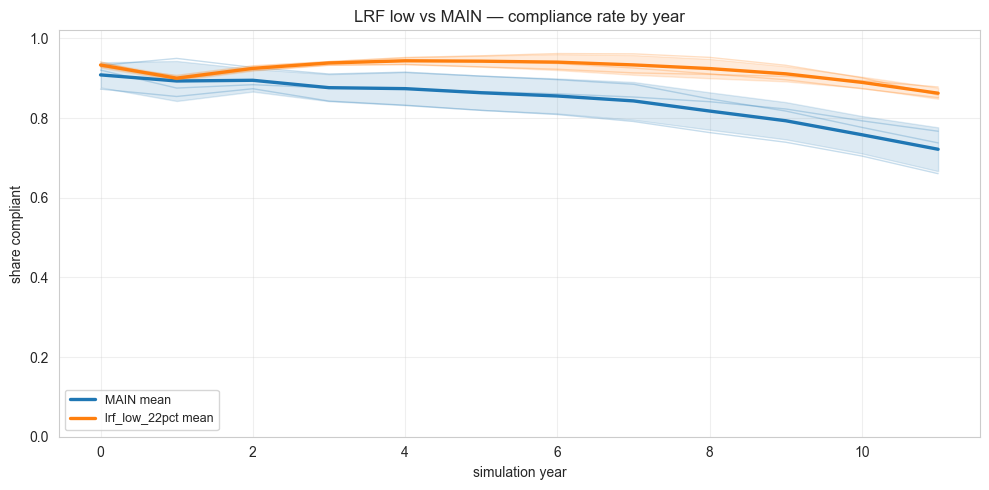

,variant,seed,mean_price,floor_touch_freq,green_pct_year12,compliance_rate,penalty_frequency,penalty_magnitude_positive,tnac_year12
0,MAIN,1729,66.963310,0.419750,73.470724,0.875062,0.124938,160.153717,10.924809
2,MAIN,6561,56.253056,0.689083,77.119780,0.796875,0.203125,194.529587,14.092499
3,MAIN,8191,47.796135,0.945833,76.509655,0.852698,0.147302,178.846375,11.706266
4,lrf_low_22pct,1729,51.550648,0.775833,73.961496,0.915312,0.084687,126.534714,22.212372
5,lrf_low_22pct,6561,45.565392,0.977917,77.448022,0.913594,0.086406,142.176987,25.338104
6,lrf_low_22pct,8191,45.904827,0.966167,76.558948,0.932021,0.067979,116.292732,24.420315


In [11]:
def _yearly_metric(variant, metric_fn, seeds=None):
    rows = []
    for (v, seed), run in runs.items():
        if v != variant or (seeds is not None and seed not in seeds):
            continue
        yr = _tail_yr(run)
        if yr.empty or 'year' not in yr.columns:
            continue
        s = metric_fn(yr, run)
        if s is None or len(s) == 0:
            continue
        df = s.reset_index()
        df.columns = ['year', 'value']
        df['variant'] = variant; df['seed'] = seed
        rows.append(df)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=['year', 'value', 'variant', 'seed'])

def _plot_yearly_variants(variants, metric_fn, title, ylabel, seeds=None, ylim=None):
    df = pd.concat([_yearly_metric(v, metric_fn, seeds=seeds) for v in variants], ignore_index=True)
    fig, ax = plt.subplots(figsize=(10, 5))
    if df.empty:
        ax.text(0.5, 0.5, 'No year-level data', ha='center', va='center', transform=ax.transAxes)
    else:
        for variant in variants:
            sub = df[df['variant'] == variant]
            if sub.empty:
                continue
            by = sub.groupby(['seed', 'year'])['value'].mean().reset_index()
            for seed, g in by.groupby('seed'):
                ax.plot(g['year'], g['value'], color=VARIANT_COLOR.get(variant), alpha=0.25, lw=1)
            agg = by.groupby('year')['value'].agg(['mean', 'std']).reset_index()
            ax.plot(agg['year'], agg['mean'], color=VARIANT_COLOR.get(variant), lw=2.4, label=f'{variant} mean')
            ax.fill_between(agg['year'], agg['mean'] - agg['std'].fillna(0), agg['mean'] + agg['std'].fillna(0),
                            color=VARIANT_COLOR.get(variant), alpha=0.15)
    ax.set(title=title, xlabel='simulation year', ylabel=ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return df

price_metric = lambda yr, run: yr.groupby('year')['clearing_price'].mean() if 'clearing_price' in yr.columns else None
green_metric = lambda yr, run: yr.groupby('year')[agent_cols(yr, 'green_frac')].mean().mean(axis=1) * 100 if agent_cols(yr, 'green_frac') else None
invest_metric = lambda yr, run: yr.groupby('year')[agent_cols(yr, 'invest_cost')].sum().sum(axis=1) if agent_cols(yr, 'invest_cost') else None
tnac_metric = lambda yr, run: yr.groupby('year')['tnac'].mean() if 'tnac' in yr.columns else None
compliance_metric = lambda yr, run: (yr[agent_cols(yr, 'shortfall')] <= 1e-6).mean(axis=1).groupby(yr['year']).mean() if agent_cols(yr, 'shortfall') else None

_plot_yearly_variants(['MAIN', 'lrf_low_22pct'], price_metric,
                      'LRF low vs MAIN — year-by-year clearing price (seed bands)', '€/tCO₂', seeds=PAIRED_SEEDS)
_plot_yearly_variants(['MAIN', 'lrf_low_22pct'], green_metric,
                      'LRF low vs MAIN — cumulative/installed green share path', 'green %', seeds=PAIRED_SEEDS, ylim=(0, 100))
_plot_yearly_variants(['MAIN', 'lrf_low_22pct'], invest_metric,
                      'LRF low vs MAIN — investment timing by simulation year', 'system invest cost (M€ per row mean)', seeds=PAIRED_SEEDS)
_plot_yearly_variants(['MAIN', 'lrf_low_22pct'], tnac_metric,
                      'LRF low vs MAIN — TNAC trajectory', 'TNAC (Mt)', seeds=PAIRED_SEEDS)
_plot_yearly_variants(['MAIN', 'lrf_low_22pct'], compliance_metric,
                      'LRF low vs MAIN — compliance rate by year', 'share compliant', seeds=PAIRED_SEEDS, ylim=(0, 1.02))

cols = ['variant', 'seed', 'mean_price', 'floor_touch_freq', 'green_pct_year12', 'compliance_rate',
        'penalty_frequency', 'penalty_magnitude_positive', 'tnac_year12']
display(summary_df[summary_df['variant'].astype(str).isin(['MAIN', 'lrf_low_22pct']) & summary_df['seed'].isin(PAIRED_SEEDS)][cols])

**Interpretation prompts for write-up.**

- If `lrf_low_22pct` has high `floor_touch_freq` and a flat price path close to `auction.price_min`, the soft cap leaves prices floor-bound.
- Scarcity begins when the LRF-low price path separates upward from the floor / MAIN path and TNAC stops accumulating.
- If green% and investment timing barely move vs MAIN, the lower LRF weakens the regulatory channel without changing strategy.

## 7. LRF High (6%) vs MAIN

C:\Users\danie\AppData\Local\Temp\ipykernel_24276\2486335180.py:39: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


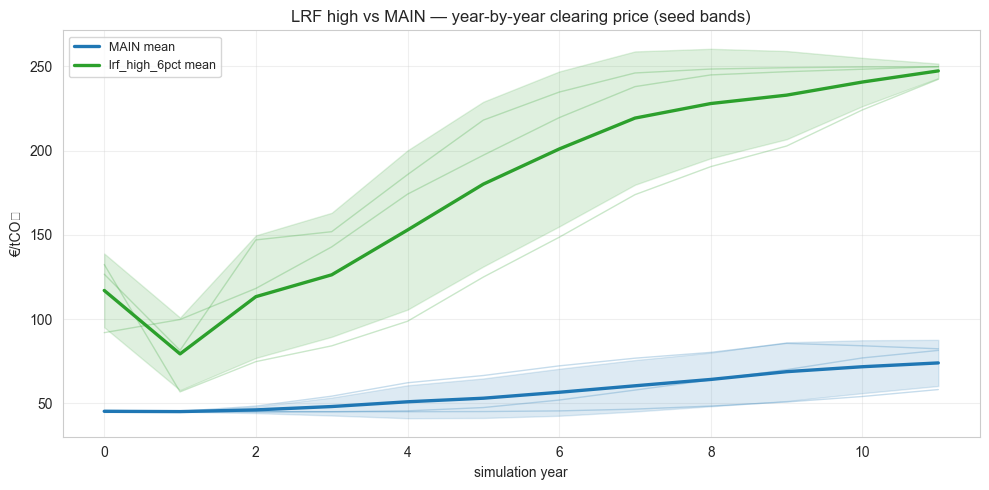

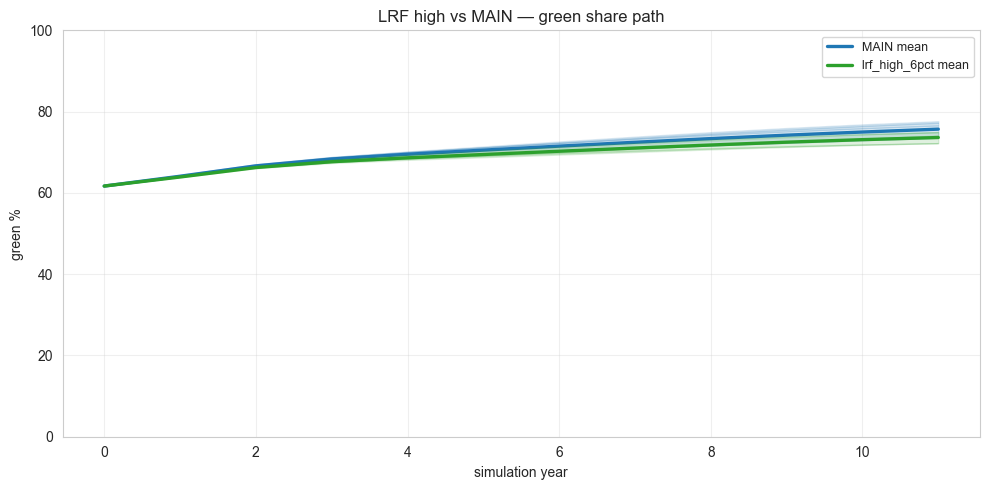

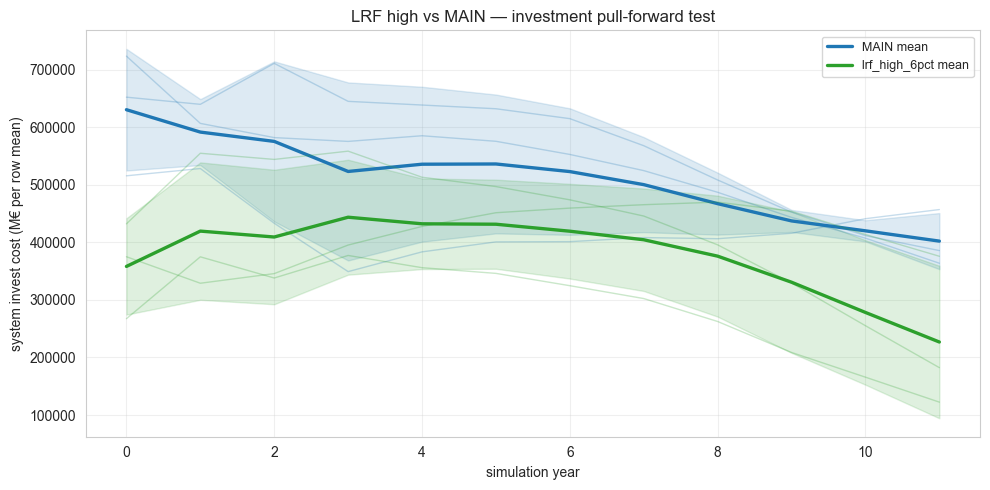

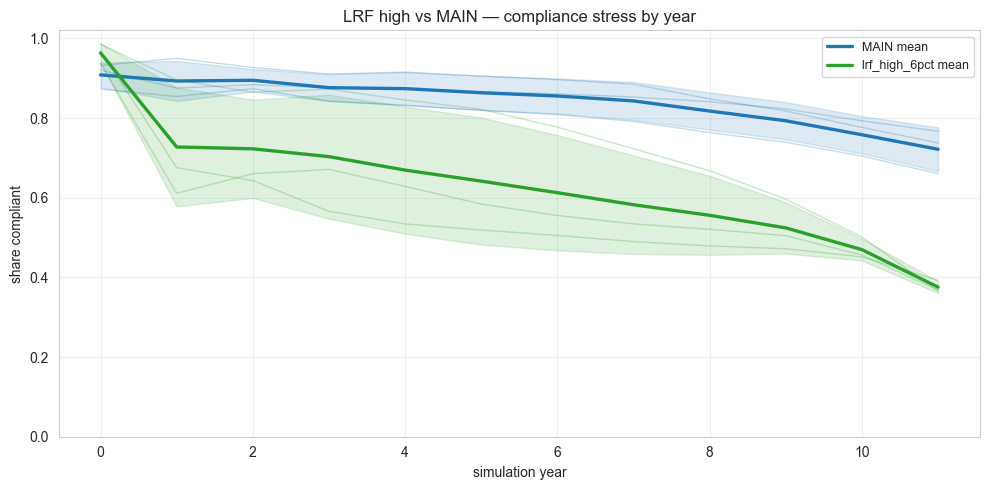

,variant,seed,mean_price,ceiling_touch_freq,green_pct_year12,compliance_rate,carry_forward_mean,carry_forward_peak,penalty_frequency,penalty_magnitude_positive
0,MAIN,1729,66.963310,0.000000,73.470724,0.875062,1.001507,7.506701,0.124938,160.153717
2,MAIN,6561,56.253056,0.000000,77.119780,0.796875,1.996645,8.656900,0.203125,194.529587
3,MAIN,8191,47.796135,0.000000,76.509655,0.852698,1.322948,41.689297,0.147302,178.846375
7,lrf_high_6pct,1729,189.248474,0.436417,73.973340,0.585990,4.649375,24.142300,0.414010,226.406967
8,lrf_high_6pct,6561,146.118057,0.179250,72.124189,0.742990,2.115828,16.197601,0.257010,168.235703
9,lrf_high_6pct,8191,199.002090,0.496333,74.818605,0.558000,5.344261,23.166199,0.442000,242.729645


In [12]:
_plot_yearly_variants(['MAIN', 'lrf_high_6pct'], price_metric,
                      'LRF high vs MAIN — year-by-year clearing price (seed bands)', '€/tCO₂', seeds=PAIRED_SEEDS)
_plot_yearly_variants(['MAIN', 'lrf_high_6pct'], green_metric,
                      'LRF high vs MAIN — green share path', 'green %', seeds=PAIRED_SEEDS, ylim=(0, 100))
_plot_yearly_variants(['MAIN', 'lrf_high_6pct'], invest_metric,
                      'LRF high vs MAIN — investment pull-forward test', 'system invest cost (M€ per row mean)', seeds=PAIRED_SEEDS)
_plot_yearly_variants(['MAIN', 'lrf_high_6pct'], compliance_metric,
                      'LRF high vs MAIN — compliance stress by year', 'share compliant', seeds=PAIRED_SEEDS, ylim=(0, 1.02))

cols = ['variant', 'seed', 'mean_price', 'ceiling_touch_freq', 'green_pct_year12', 'compliance_rate',
        'carry_forward_mean', 'carry_forward_peak', 'penalty_frequency', 'penalty_magnitude_positive']
display(summary_df[summary_df['variant'].astype(str).isin(['MAIN', 'lrf_high_6pct']) & summary_df['seed'].isin(PAIRED_SEEDS)][cols])

**Interpretation prompts for write-up.**

- If `ceiling_touch_freq` rises materially, the aggressive cap pushes bids toward the price ceiling.
- Scarcity hits earlier if the high-LRF price path rises above MAIN in earlier years, not just in year 12.
- Compliance failure type matters: high mean/peak carry-forward indicates debt cascades, while high positive penalty magnitude indicates direct non-compliance costs.

## 8. Cross-LRF Synthesis (2.2% / 4.3% / 6%)

C:\Users\danie\AppData\Local\Temp\ipykernel_24276\2486335180.py:39: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


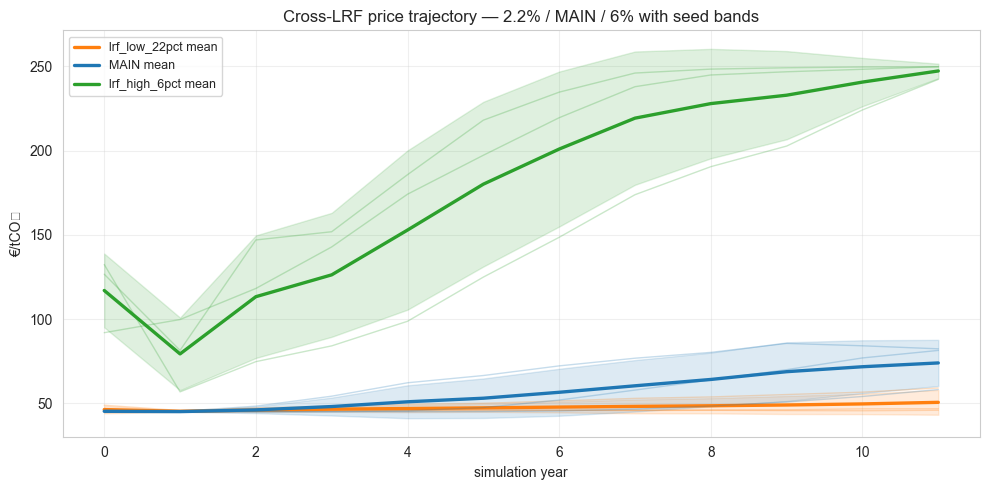

C:\Users\danie\AppData\Local\Temp\ipykernel_24276\561609426.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vals, x='variant', y=metric, order=lrf_variants, errorbar='sd', palette=VARIANT_COLOR, ax=ax)
C:\Users\danie\AppData\Local\Temp\ipykernel_24276\561609426.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vals, x='variant', y=metric, order=lrf_variants, errorbar='sd', palette=VARIANT_COLOR, ax=ax)
C:\Users\danie\AppData\Local\Temp\ipykernel_24276\561609426.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vals,

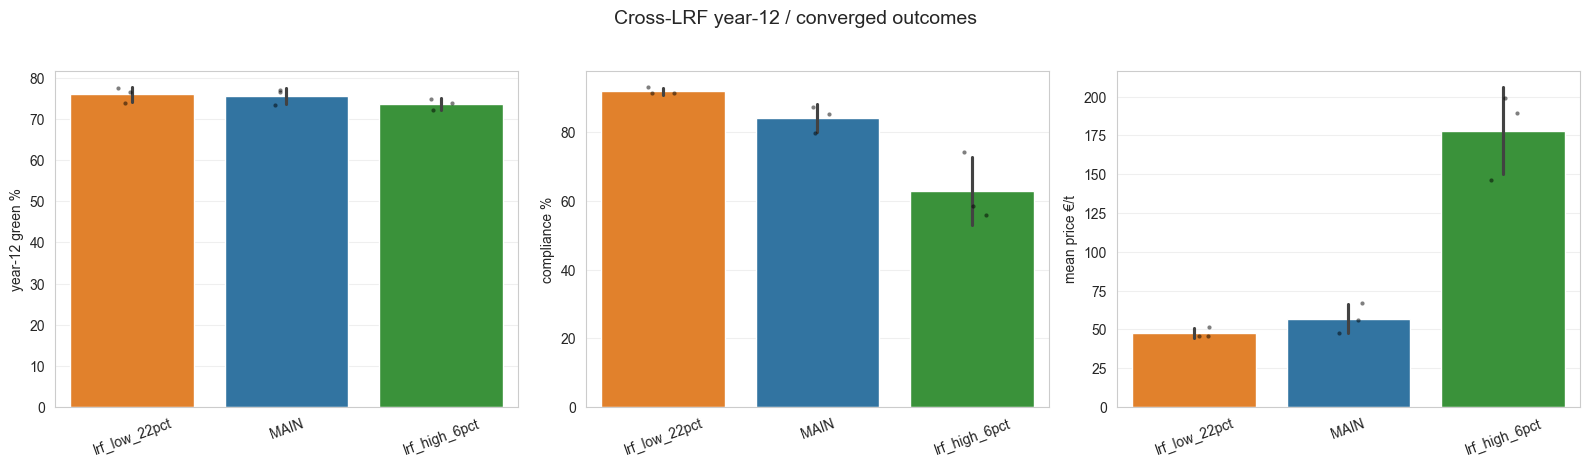

Overall decarbonization elasticity: -0.573 percentage-points green per percentage-point LRF


,lrf_pp,green_pct,mean_price,compliance,decarbonization_elasticity_to_next
0,2.2,75.989489,47.673622,0.920309,NaN
1,4.4,75.700053,57.004167,0.841545,-0.131562
2,6.3,73.638711,178.122874,0.628993,-1.084916


In [13]:
lrf_variants = ['lrf_low_22pct', 'MAIN', 'lrf_high_6pct']
_plot_yearly_variants(lrf_variants, price_metric,
                      'Cross-LRF price trajectory — 2.2% / MAIN / 6% with seed bands', '€/tCO₂', seeds=PAIRED_SEEDS)

lrf_summary = summary_df[summary_df['variant'].astype(str).isin(lrf_variants) & summary_df['seed'].isin(PAIRED_SEEDS)].copy()

def _lrf_pp_for_variant(variant):
    vals = []
    for (v, _seed), run in runs.items():
        if v == variant:
            ets = run['config'].get('ets', {})
            val = ets.get('lrf_phase2', ets.get('lrf_phase1'))
            vals.append(float(val) * 100.0 if val is not None else np.nan)
    return float(np.nanmean(vals)) if vals else np.nan

lrf_map = {v: _lrf_pp_for_variant(v) for v in lrf_variants}
lrf_summary['lrf_pp'] = lrf_summary['variant'].astype(str).map(lrf_map)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric, ylabel in zip(axes, ['green_pct_year12', 'compliance_rate', 'mean_price'], ['year-12 green %', 'compliance %', 'mean price €/t']):
    vals = lrf_summary.copy()
    if metric == 'compliance_rate':
        vals[metric] *= 100
    sns.barplot(data=vals, x='variant', y=metric, order=lrf_variants, errorbar='sd', palette=VARIANT_COLOR, ax=ax)
    sns.stripplot(data=vals, x='variant', y=metric, order=lrf_variants, color='black', alpha=0.5, size=3, ax=ax)
    ax.set_xlabel(''); ax.set_ylabel(ylabel); ax.tick_params(axis='x', rotation=20); ax.grid(True, alpha=0.3, axis='y')
fig.suptitle('Cross-LRF year-12 / converged outcomes', fontsize=14, y=1.03)
plt.tight_layout(); plt.show()

lrf_means = lrf_summary.groupby('lrf_pp', as_index=False).agg(green_pct=('green_pct_year12', 'mean'), mean_price=('mean_price', 'mean'), compliance=('compliance_rate', 'mean'))
lrf_means = lrf_means.sort_values('lrf_pp')
if len(lrf_means) >= 2:
    lrf_means['decarbonization_elasticity_to_next'] = lrf_means['green_pct'].diff() / lrf_means['lrf_pp'].diff()
    overall_elasticity = ((lrf_means['green_pct'].iloc[-1] - lrf_means['green_pct'].iloc[0]) /
                          (lrf_means['lrf_pp'].iloc[-1] - lrf_means['lrf_pp'].iloc[0]))
else:
    overall_elasticity = np.nan
print(f'Overall decarbonization elasticity: {overall_elasticity:.3f} percentage-points green per percentage-point LRF')
display(lrf_means)

## 9. No Market Stability vs MAIN

C:\Users\danie\AppData\Local\Temp\ipykernel_24276\2486335180.py:39: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


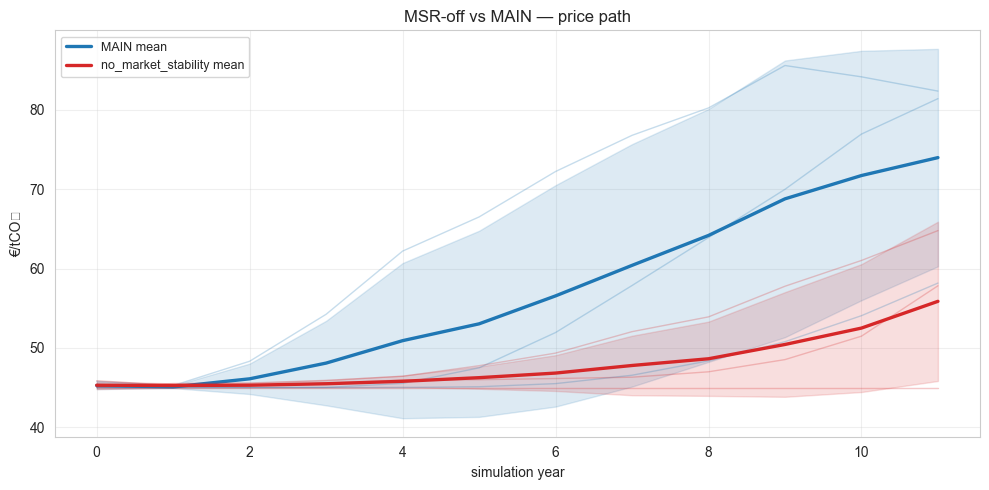

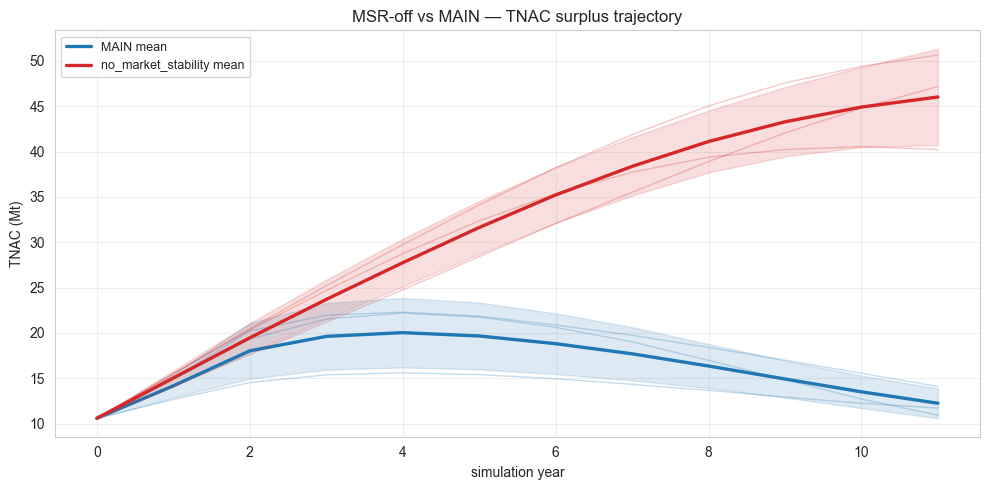

,variant,seed,msr_withhold_events,msr_release_events,msr_withheld_total,msr_released_total,mean_price,within_episode_price_std,tnac_year12,bank_total_year12,unsold_frequency,floor_touch_freq,ceiling_touch_freq
0,MAIN,1729,9488,0,40393.207031,0.0000,66.963310,24.691515,10.924809,9.691194,0.010333,0.419750,0.0
2,MAIN,6561,9872,0,44282.257812,0.0000,56.253056,19.755203,14.092499,12.688789,0.005583,0.689083,0.0
3,MAIN,8191,7694,33,22209.158203,48.0513,47.796135,5.435904,11.706266,11.092328,0.625750,0.945833,0.0
10,no_market_stability,1729,0,0,0.000000,0.0000,47.602474,6.939629,40.226078,39.398102,0.003083,0.914083,0.0
11,no_market_stability,6561,0,0,0.000000,0.0000,45.000000,0.000000,47.194408,49.053288,0.676667,1.000000,0.0
12,no_market_stability,8191,0,0,0.000000,0.0000,51.256756,12.217535,50.642204,51.230450,0.064583,0.826083,0.0


MSR triggered in MAIN: total event count across loaded tail windows = 35899


C:\Users\danie\AppData\Local\Temp\ipykernel_24276\330205796.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


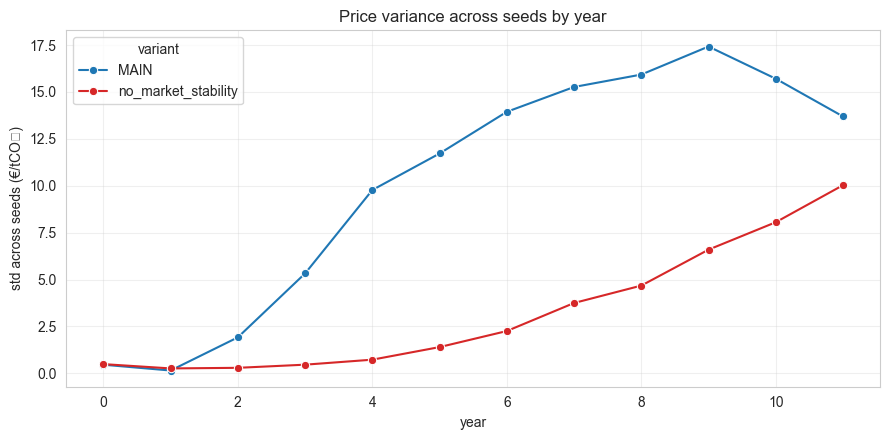

In [14]:
_plot_yearly_variants(['MAIN', 'no_market_stability'], price_metric,
                      'MSR-off vs MAIN — price path', '€/tCO₂', seeds=PAIRED_SEEDS)
_plot_yearly_variants(['MAIN', 'no_market_stability'], tnac_metric,
                      'MSR-off vs MAIN — TNAC surplus trajectory', 'TNAC (Mt)', seeds=PAIRED_SEEDS)

msr_cols = ['variant', 'seed', 'msr_withhold_events', 'msr_release_events', 'msr_withheld_total', 'msr_released_total',
            'mean_price', 'within_episode_price_std', 'tnac_year12', 'bank_total_year12', 'unsold_frequency',
            'floor_touch_freq', 'ceiling_touch_freq']
msr_df = summary_df[summary_df['variant'].astype(str).isin(['MAIN', 'no_market_stability']) & summary_df['seed'].isin(PAIRED_SEEDS)][msr_cols]
display(msr_df)

main_msr_events = summary_df[summary_df['variant'].astype(str).eq('MAIN')][['msr_withhold_events', 'msr_release_events']].sum().sum()
if main_msr_events <= 0:
    print('FLAG: MSR never triggered in loaded MAIN runs. MAIN vs no_market_stability is a null comparison for MSR mechanics; interpret only unsold-to-MSR / config side effects.')
else:
    print(f'MSR triggered in MAIN: total event count across loaded tail windows = {int(main_msr_events)}')

# Across-seed price std by year: the MSR is meant to damp cross-seed noise as well as within-episode volatility.
price_paths = pd.concat([_yearly_metric(v, price_metric, seeds=PAIRED_SEEDS) for v in ['MAIN', 'no_market_stability']], ignore_index=True)
if not price_paths.empty:
    across_seed = price_paths.groupby(['variant', 'year'])['value'].std().reset_index(name='across_seed_price_std')
    fig, ax = plt.subplots(figsize=(9, 4.5))
    sns.lineplot(data=across_seed, x='year', y='across_seed_price_std', hue='variant', marker='o', ax=ax, palette=VARIANT_COLOR)
    ax.set(title='Price variance across seeds by year', ylabel='std across seeds (€/tCO₂)', xlabel='year')
    ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 10. All-Financial Objectives vs MAIN

C:\Users\danie\AppData\Local\Temp\ipykernel_24276\2486335180.py:39: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


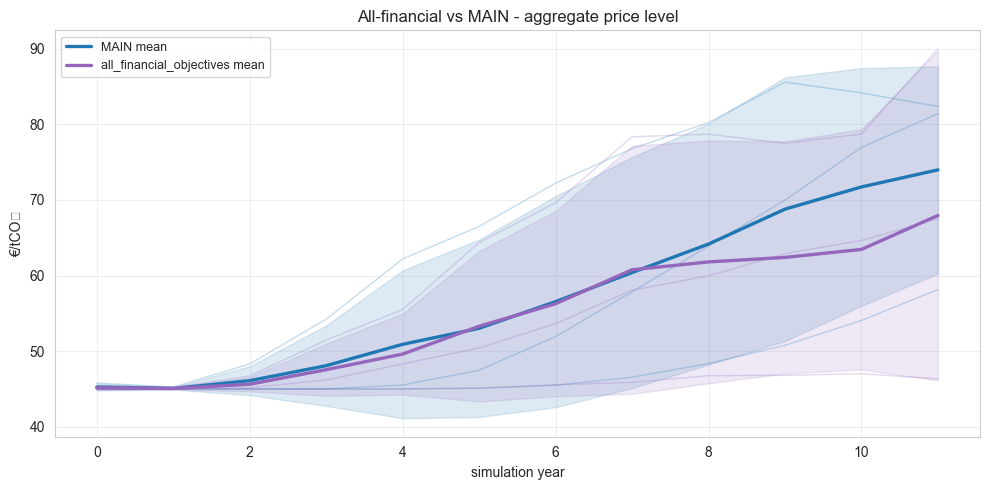

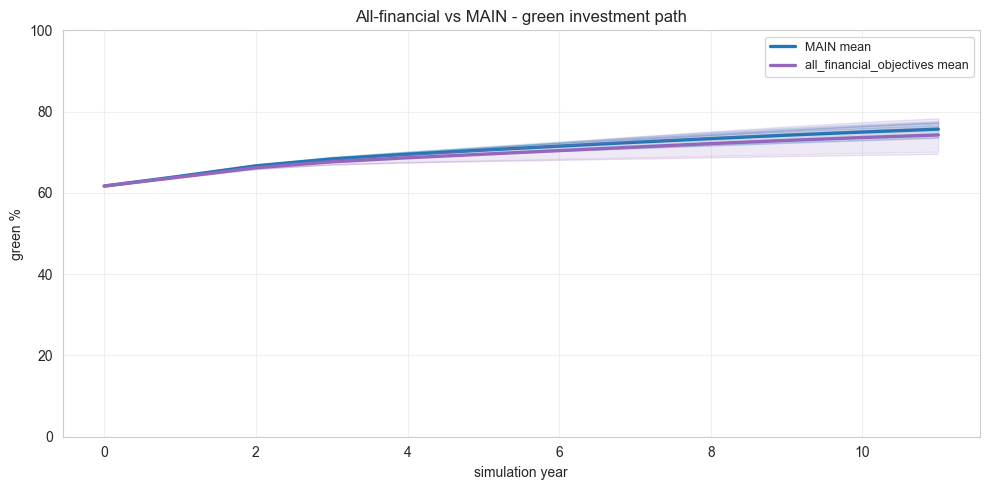

,variant,seed,mean_price,green_pct_year12,investment_total,compliance_rate,auction_gini,bank_total_year12,secondary_volume,secondary_buyers_executed,secondary_sellers_executed
0,MAIN,1729,66.963310,73.470724,428.318695,0.875062,0.358308,9.691194,43.932224,1.373750,1.568583
2,MAIN,6561,56.253056,77.119780,571.575439,0.796875,0.373450,12.688789,27.110363,0.882833,1.052000
3,MAIN,8191,47.796135,76.509655,535.529297,0.852698,0.305214,11.092328,40.209431,1.423500,1.805083
13,all_financial_objectives,1729,53.905163,77.179533,584.804810,0.887969,0.330095,11.875740,35.934071,1.254667,1.388167
14,all_financial_objectives,6561,65.127045,69.528711,165.145538,0.823187,0.336031,5.702539,34.565742,1.114917,1.299667
15,all_financial_objectives,8191,45.711903,76.083511,477.663116,0.842187,0.429197,7.712478,46.174217,1.558833,1.784833


bid_price  invest_frac_post_clip  green_frac  bank_end  trade_qty  reward  reward_base  reward_shaping
variant                  weighting                                                                                                           
MAIN                     Balanced ESG    84.9316                 0.0303      0.7255    2.1516    -0.2193  0.4080       0.3646          0.0433
                         Financial      111.3360                 0.0059      0.6798    1.9351     0.2193  0.0362      -0.0055          0.0416
all_financial_objectives Financial      102.0497                 0.0059      0.6936    1.9736     0.0000  0.2042       0.1612          0.0430

MAIN vs all-financial objectives - per-episode mean/std summary: 6,000 loaded tail episodes across 6 runs (seeds=[1729, 8191, 6561]). Seed=ALL aggregates the included seeds for that variant.


,variant,seed,n_episodes,price_any_year_mean_mean,price_any_year_mean_std,price_final_year_mean,price_final_year_std,green_frac_year12_mean,green_frac_year12_std,penalty_total_mean,penalty_total_std,shortfall_total_mean,shortfall_total_std,compliance_rate_mean,compliance_rate_std,reward_base_total_mean,reward_base_total_std,stressed_cell_rate_mean,stressed_cell_rate_std,stressed_year_rate_mean,stressed_year_rate_std,stress_gap_total_mean,stress_gap_total_std,bank_year12_total_mean,bank_year12_total_std,investment_total_mean,investment_total_std,secondary_price_vwap_mean,secondary_price_vwap_std,secondary_sales_volume_mean,secondary_sales_volume_std,secondary_volume_mean,secondary_volume_std,quality_score_mean,quality_score_std
0,MAIN,ALL,3000,57.004200,10.9124,73.968201,33.518501,0.7570,0.0224,2747.759277,1915.202148,17.284401,11.816700,0.8415,0.0644,17.240499,17.9704,0.5522,0.0345,1.0,0.0,72.078400,11.6858,11.1574,3.0767,6141.693848,887.189392,148.5885,37.4964,37.084000,8.9386,37.084000,8.9386,1.4627,0.3114
2,MAIN,1729,1000,66.963303,9.0383,82.345299,32.277699,0.7347,0.0158,1920.884033,1182.704712,12.018100,7.396600,0.8751,0.0478,15.983300,14.4634,0.5519,0.0329,1.0,0.0,74.485603,8.4373,9.6912,1.8101,5139.824707,501.575714,155.1066,23.6432,43.932201,5.1574,43.932201,5.1574,1.7124,0.2734
3,MAIN,6561,1000,56.253101,6.0804,81.394997,30.346201,0.7712,0.0155,3793.326904,1486.469849,23.959700,9.406400,0.7969,0.0529,8.410900,13.8440,0.5625,0.0295,1.0,0.0,76.577599,10.0980,12.6888,1.9876,6858.905762,439.414795,175.7098,36.1359,27.110399,5.2085,27.110399,5.2085,1.3446,0.2357
4,MAIN,8191,1000,47.796101,7.3549,58.164200,32.163700,0.7651,0.0159,2529.066406,2361.434082,15.875400,14.200100,0.8527,0.0642,27.327101,19.6758,0.5422,0.0376,1.0,0.0,65.171898,12.7664,11.0923,4.0849,6426.351562,563.437805,114.9490,21.0802,40.209400,5.4617,40.209400,5.4617,1.3310,0.2590
1,all_financial_objectives,ALL,3000,54.914700,10.5910,67.941902,36.406200,0.7426,0.0371,3779.166748,3421.008057,23.700001,21.138700,0.8511,0.0570,15.477600,18.4524,0.5465,0.0495,1.0,0.0,80.172798,23.2876,8.4303,3.4621,4910.454102,2186.687256,98.3378,27.1367,38.891300,7.3248,38.891300,7.3248,1.2604,0.3760
5,all_financial_objectives,1729,1000,53.905201,6.1113,67.510201,25.852501,0.7718,0.0200,2037.275146,2104.099854,12.844200,12.812700,0.8880,0.0463,13.357200,12.3746,0.5398,0.0322,1.0,0.0,63.897202,13.5586,11.8757,2.3408,7017.658203,645.729370,73.2927,14.3190,35.934101,5.0610,35.934101,5.0610,1.6022,0.2944
6,all_financial_objectives,6561,1000,65.126999,10.2731,89.956902,47.972000,0.6953,0.0130,3102.866699,1614.478027,19.568501,10.177600,0.8232,0.0548,3.118000,16.2048,0.5952,0.0339,1.0,0.0,79.440697,11.2968,5.7025,1.9776,1981.746460,239.938904,113.4289,22.2468,34.565701,4.8768,34.565701,4.8768,1.0552,0.3095
7,all_financial_objectives,8191,1000,45.711899,1.9127,46.358601,7.588700,0.7608,0.0117,6197.359375,4330.238281,38.687302,26.716801,0.8422,0.0490,29.957500,15.4640,0.5045,0.0314,1.0,0.0,97.180603,27.5921,7.7125,2.5972,5731.957520,416.686005,108.2917,23.5731,46.174198,5.5758,46.174198,5.5758,1.1239,0.2534


In [15]:
_plot_yearly_variants(['MAIN', 'all_financial_objectives'], price_metric,
                      'All-financial vs MAIN - aggregate price level', '€/tCO₂', seeds=PAIRED_SEEDS)
_plot_yearly_variants(['MAIN', 'all_financial_objectives'], green_metric,
                      'All-financial vs MAIN - green investment path', 'green %', seeds=PAIRED_SEEDS, ylim=(0, 100))

cols = ['variant', 'seed', 'mean_price', 'green_pct_year12', 'investment_total', 'compliance_rate',
        'auction_gini', 'bank_total_year12', 'secondary_volume', 'secondary_buyers_executed', 'secondary_sellers_executed']
display(summary_df[summary_df['variant'].astype(str).isin(['MAIN', 'all_financial_objectives']) & summary_df['seed'].isin(PAIRED_SEEDS)][cols])

# Secondary market directional role by agent group (MAIN has mixed objectives; all_fin should collapse to Financial).
def agent_group_table(variants, seeds=PAIRED_SEEDS):
    rows = []
    for (variant, seed), run in runs.items():
        if variant not in variants or seed not in seeds:
            continue
        yr = _tail_yr(run)
        ep = _tail_ep(run)
        for i in range(N_AGENTS):
            row = {'variant': variant, 'seed': seed, 'agent': f'A{i+1}', 'archetype': _agent_archetype(i), 'weighting': _agent_weighting(run, i)}
            for prefix, source in [('bid_price', yr), ('invest_frac_post_clip', yr), ('green_frac', yr), ('bank_end', yr),
                                   ('trade_qty', yr), ('sec_qty_action', yr), ('shortfall', yr), ('penalty', yr),
                                   ('reward', yr), ('reward_base', yr), ('reward_shaping', yr), ('invest_cost', yr)]:
                col = f'{prefix}_A{i+1}'
                row[prefix] = _safe_mean(source[col]) if col in source.columns else np.nan
            rows.append(row)
    return pd.DataFrame(rows)

EPISODE_COMPARISON_METRICS = [
    'price_any_year_mean', 'price_final_year', 'green_frac_year12',
    'penalty_total', 'shortfall_total', 'compliance_rate', 'reward_base_total',
    'stressed_cell_rate', 'stressed_year_rate', 'stress_gap_total',
    'bank_year12_total', 'investment_total', 'secondary_price_vwap',
    'secondary_sales_volume', 'secondary_volume', 'quality_score',
]

def _merge_episode_metric(per_episode, series, name):
    if series is None or len(series) == 0:
        return per_episode
    s = pd.Series(series).replace([np.inf, -np.inf], np.nan).rename(name).reset_index()
    if 'episode' not in s.columns:
        s = s.rename(columns={s.columns[0]: 'episode'})
    return per_episode.merge(s[['episode', name]], on='episode', how='left')

def _combine_episode_fallback(per_episode, series, name):
    if series is None or len(series) == 0:
        return per_episode
    fallback_col = f'_{name}_fallback'
    s = pd.Series(series).replace([np.inf, -np.inf], np.nan).rename(fallback_col).reset_index()
    if 'episode' not in s.columns:
        s = s.rename(columns={s.columns[0]: 'episode'})
    per_episode = per_episode.merge(s[['episode', fallback_col]], on='episode', how='left')
    if name in per_episode.columns:
        per_episode[name] = per_episode[name].combine_first(per_episode[fallback_col])
    else:
        per_episode[name] = per_episode[fallback_col]
    return per_episode.drop(columns=[fallback_col])

def _episode_vwap(values, weights, episodes):
    data = pd.DataFrame({'episode': episodes, 'value': values, 'weight': weights}).replace([np.inf, -np.inf], np.nan)
    out = {}
    for episode, g in data.groupby('episode', sort=True):
        valid = g['value'].notna() & g['weight'].fillna(0).gt(0)
        if valid.any():
            out[episode] = float(np.average(g.loc[valid, 'value'], weights=g.loc[valid, 'weight']))
        else:
            vals = g['value'].replace(0, np.nan).dropna()
            out[episode] = float(vals.mean()) if len(vals) else np.nan
    return pd.Series(out, name='secondary_price_vwap')

def _auction_stress_frames(yr):
    flags, gaps = [], []
    for i in range(N_AGENTS):
        alloc_col = f'alloc_A{i+1}'
        need_col = f'estimate_need_A{i+1}'
        emissions_col = f'emissions_A{i+1}'
        cf_col = f'carry_forward_start_A{i+1}'
        if alloc_col not in yr.columns:
            continue
        required_parts = []
        if need_col in yr.columns:
            required_parts.append(yr[need_col])
        if emissions_col in yr.columns and cf_col in yr.columns:
            required_parts.append(yr[emissions_col].fillna(0) + yr[cf_col].fillna(0))
        elif emissions_col in yr.columns:
            required_parts.append(yr[emissions_col])
        if not required_parts:
            continue
        required = pd.concat(required_parts, axis=1).max(axis=1)
        gap = (required - yr[alloc_col].fillna(0)).clip(lower=0)
        flags.append(gap > 1e-6)
        gaps.append(gap)
    if not flags:
        return None, None
    return pd.concat(flags, axis=1), pd.concat(gaps, axis=1)

def _episode_metric_frame(variants, seeds=None, n=TAIL_EPISODES):
    rows = []
    variants = list(variants)
    for (variant, seed), run in runs.items():
        if variant not in variants or (seeds is not None and seed not in seeds):
            continue
        ep = _tail_ep(run, n)
        yr = _tail_yr(run, n)
        episode_values = set()
        if not ep.empty and 'episode' in ep.columns:
            episode_values.update(ep['episode'].dropna().astype(int).unique())
        if not yr.empty and 'episode' in yr.columns:
            episode_values.update(yr['episode'].dropna().astype(int).unique())
        if not episode_values:
            continue
        per_episode = pd.DataFrame({'episode': sorted(episode_values)})
        per_episode['variant'] = variant
        per_episode['seed'] = int(seed)

        if not yr.empty and 'episode' in yr.columns:
            if 'clearing_price' in yr.columns:
                per_episode = _merge_episode_metric(per_episode, yr.groupby('episode')['clearing_price'].mean(), 'price_any_year_mean')
                yT = _yearT(yr)
                if not yT.empty:
                    per_episode = _merge_episode_metric(per_episode, yT.groupby('episode')['clearing_price'].mean(), 'price_final_year')
            else:
                yT = _yearT(yr)

            gf_cols = agent_cols(yr, 'green_frac')
            if gf_cols and not yT.empty:
                per_episode = _merge_episode_metric(per_episode, yT[gf_cols].mean(axis=1).groupby(yT['episode']).mean(), 'green_frac_year12')

            pen_cols = agent_cols(yr, 'penalty')
            if pen_cols:
                per_episode = _merge_episode_metric(per_episode, yr[pen_cols].sum(axis=1).groupby(yr['episode']).sum(), 'penalty_total')
            sf_cols = agent_cols(yr, 'shortfall')
            if sf_cols:
                per_episode = _merge_episode_metric(per_episode, yr[sf_cols].sum(axis=1).groupby(yr['episode']).sum(), 'shortfall_total')
                per_episode = _merge_episode_metric(per_episode, (yr[sf_cols] <= 1e-6).mean(axis=1).groupby(yr['episode']).mean(), 'compliance_rate')
            rb_cols = agent_cols(yr, 'reward_base')
            if rb_cols:
                per_episode = _merge_episode_metric(per_episode, yr[rb_cols].sum(axis=1).groupby(yr['episode']).sum(), 'reward_base_total')
            inv_cols = agent_cols(yr, 'invest_cost')
            if inv_cols:
                per_episode = _merge_episode_metric(per_episode, yr[inv_cols].sum(axis=1).groupby(yr['episode']).sum(), 'investment_total')
            bank_cols = agent_cols(yr, 'bank_end')
            if bank_cols and not yT.empty:
                per_episode = _merge_episode_metric(per_episode, yT[bank_cols].sum(axis=1).groupby(yT['episode']).mean(), 'bank_year12_total')

            stress_flags, stress_gaps = _auction_stress_frames(yr)
            if stress_flags is not None:
                per_episode = _merge_episode_metric(per_episode, stress_flags.mean(axis=1).groupby(yr['episode']).mean(), 'stressed_cell_rate')
                per_episode = _merge_episode_metric(per_episode, stress_flags.any(axis=1).groupby(yr['episode']).mean(), 'stressed_year_rate')
                per_episode = _merge_episode_metric(per_episode, stress_gaps.sum(axis=1).groupby(yr['episode']).sum(), 'stress_gap_total')

            trade_cols = agent_cols(yr, 'trade_qty')
            if trade_cols:
                sales_volume = (-yr[trade_cols]).clip(lower=0).sum(axis=1)
                per_episode = _merge_episode_metric(per_episode, sales_volume.groupby(yr['episode']).sum(), 'secondary_sales_volume')
                if 'secondary_price' in yr.columns:
                    per_episode = _merge_episode_metric(per_episode, _episode_vwap(yr['secondary_price'], sales_volume, yr['episode']), 'secondary_price_vwap')

        if not ep.empty and 'episode' in ep.columns:
            for source_col, out_col in [('quality_score', 'quality_score'), ('secondary_volume', 'secondary_volume')]:
                if source_col in ep.columns:
                    per_episode = _merge_episode_metric(per_episode, ep.groupby('episode')[source_col].mean(), out_col)
            for fallback_col in ['secondary_avg_price', 'secondary_price']:
                if fallback_col in ep.columns:
                    per_episode = _combine_episode_fallback(per_episode, ep.groupby('episode')[fallback_col].mean(), 'secondary_price_vwap')
                    break

        rows.append(per_episode)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

def episode_comparison_table(variants, seeds=None, n=TAIL_EPISODES):
    episode_df = _episode_metric_frame(variants, seeds=seeds, n=n)
    if episode_df.empty:
        return pd.DataFrame(), episode_df
    metrics = [m for m in EPISODE_COMPARISON_METRICS if m in episode_df.columns]

    def summarize(group_cols):
        grouped = episode_df.groupby(group_cols, dropna=False)
        table = grouped[metrics].agg(['mean', 'std'])
        table.columns = [f'{metric}_{stat}' for metric, stat in table.columns]
        table.insert(0, 'n_episodes', grouped.size())
        return table.reset_index()

    variant_summary = summarize(['variant'])
    variant_summary.insert(1, 'seed', 'ALL')
    seed_summary = summarize(['variant', 'seed'])
    seed_summary['seed'] = seed_summary['seed'].astype(str)
    table = pd.concat([variant_summary, seed_summary], ignore_index=True, sort=False)
    variant_order = {v: i for i, v in enumerate(variants)}
    table['_variant_order'] = table['variant'].map(variant_order).fillna(len(variant_order))
    table['_seed_order'] = table['seed'].map(lambda s: -1 if s == 'ALL' else int(s))
    table = table.sort_values(['_variant_order', '_seed_order']).drop(columns=['_variant_order', '_seed_order'])
    numeric_cols = table.select_dtypes(include='number').columns
    table[numeric_cols] = table[numeric_cols].round(4)
    return table, episode_df

def display_episode_comparison(variants, title, seeds=None, n=TAIL_EPISODES):
    table, episode_df = episode_comparison_table(variants, seeds=seeds, n=n)
    if episode_df.empty:
        print(f'{title}: no episode-level rows available.')
        return table, episode_df
    n_runs = episode_df[['variant', 'seed']].drop_duplicates().shape[0]
    seed_note = 'all loaded seeds' if seeds is None else f'seeds={list(seeds)}'
    print(f'{title}: {len(episode_df):,} loaded tail episodes across {n_runs} runs ({seed_note}). Seed=ALL aggregates the included seeds for that variant.')
    display(table)
    return table, episode_df

group_df = agent_group_table(['MAIN', 'all_financial_objectives'])
if not group_df.empty:
    display(group_df.groupby(['variant', 'weighting'])[['bid_price', 'invest_frac_post_clip', 'green_frac', 'bank_end', 'trade_qty', 'reward', 'reward_base', 'reward_shaping']].mean().round(4))

all_fin_episode_summary, all_fin_episode_rows = display_episode_comparison(
    ['MAIN', 'all_financial_objectives'],
    'MAIN vs all-financial objectives - per-episode mean/std summary',
    seeds=PAIRED_SEEDS,
)


**Interpretation prompts for write-up.**

- If all-financial green investment remains high, the carbon-cost NPV channel is sufficient to decarbonize even without ESG utility.
- If auction Gini rises, removing ESG may concentrate allowances among agents with stronger financial compliance incentives.
- Secondary-market buy/sell counts and signed `trade_qty` show whether objective removal changes who provides liquidity.

## 11. Balanced Identical vs MAIN

,variant,seed,bid_price_agent_var,invest_frac_agent_var,bank_agent_var,mean_price,green_pct_year12,compliance_rate,secondary_volume
0,MAIN,1729,2309.026611,0.000180,3.703675,66.963310,73.470724,0.875062,43.932224
2,MAIN,6561,2283.851318,0.000177,6.368018,56.253056,77.119780,0.796875,27.110363
3,MAIN,8191,1367.592285,0.000183,4.539381,47.796135,76.509655,0.852698,40.209431
16,balanced_identical,1729,2443.035645,0.000189,6.892633,52.172863,61.675537,0.650250,38.256451
17,balanced_identical,6561,1514.242310,0.000189,7.231146,90.139061,57.866687,0.447073,12.071053
18,balanced_identical,8191,2108.895020,0.000189,6.564644,48.191730,63.959104,0.725875,44.111317


C:\Users\danie\AppData\Local\Temp\ipykernel_24276\460732173.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='variant', y=metric, order=[v for v in VARIANT_ORDER if v in set(df['variant'].astype(str))],
C:\Users\danie\AppData\Local\Temp\ipykernel_24276\460732173.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='variant', y=metric, order=[v for v in VARIANT_ORDER if v in set(df['variant'].astype(str))],
C:\Users\danie\AppData\Local\Temp\ipykernel_24276\460732173.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplo

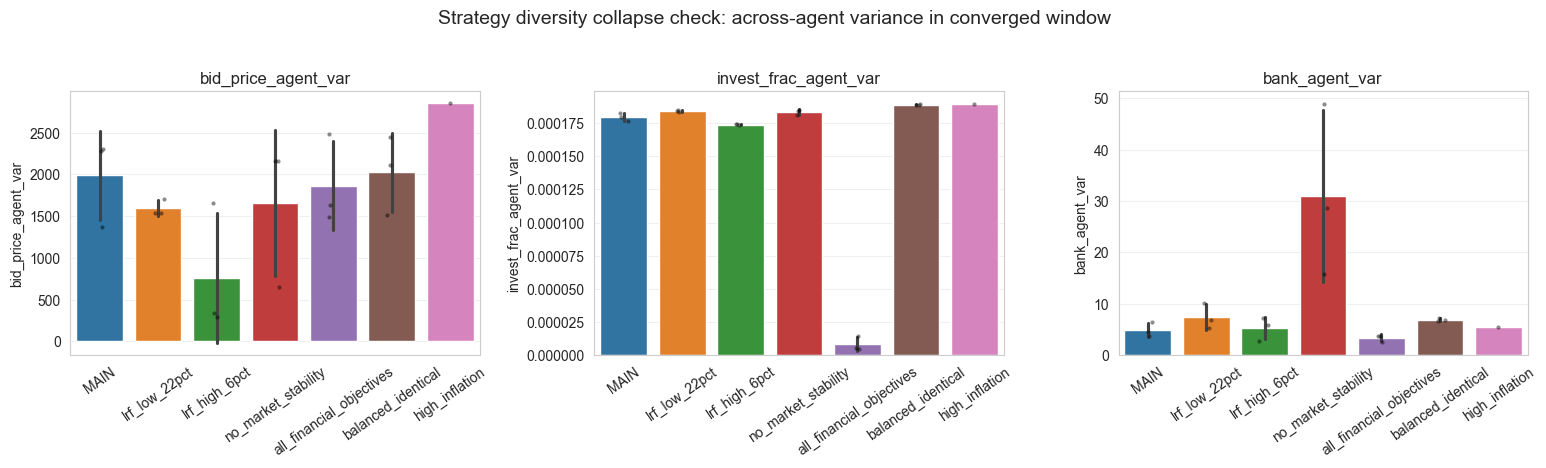

bid_price          invest_frac_post_clip         green_frac         bank_end         trade_qty         shortfall           penalty          
                                     mean      std                  mean     std       mean     std     mean     std      mean     std      mean     std      mean       std
variant            weighting                                                                                                                                                
balanced_identical Balanced ESG  109.7631  47.5986                0.0303  0.0035     0.5842  0.0276   3.3284  1.5436    -0.194  1.0117    0.2716  0.4216   44.5714   69.4903
                   Financial     123.8967  34.7445                0.0050  0.0000     0.5851  0.0288   0.6313  1.1890     0.194  0.5487    1.1974  0.7294  190.1931  117.5883

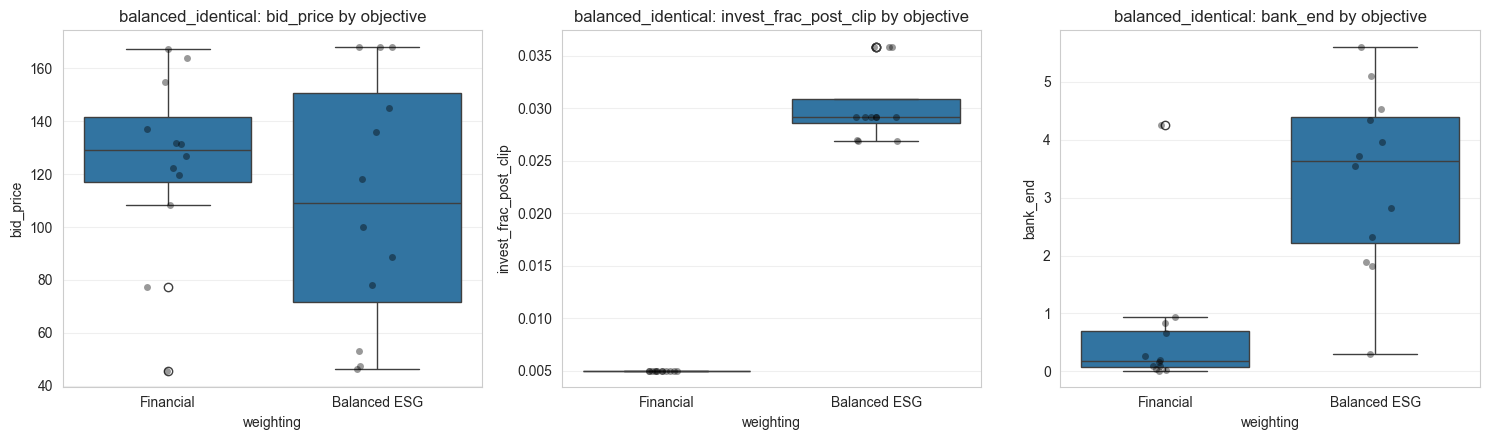

MAIN vs balanced-identical - per-episode mean/std summary: 6,000 loaded tail episodes across 6 runs (seeds=[1729, 8191, 6561]). Seed=ALL aggregates the included seeds for that variant.


,variant,seed,n_episodes,price_any_year_mean_mean,price_any_year_mean_std,price_final_year_mean,price_final_year_std,green_frac_year12_mean,green_frac_year12_std,penalty_total_mean,penalty_total_std,shortfall_total_mean,shortfall_total_std,compliance_rate_mean,compliance_rate_std,reward_base_total_mean,reward_base_total_std,stressed_cell_rate_mean,stressed_cell_rate_std,stressed_year_rate_mean,stressed_year_rate_std,stress_gap_total_mean,stress_gap_total_std,bank_year12_total_mean,bank_year12_total_std,investment_total_mean,investment_total_std,secondary_price_vwap_mean,secondary_price_vwap_std,secondary_sales_volume_mean,secondary_sales_volume_std,secondary_volume_mean,secondary_volume_std,quality_score_mean,quality_score_std
0,MAIN,ALL,3000,57.004200,10.912400,73.968201,33.518501,0.7570,0.0224,2747.759277,1915.202148,17.284401,11.816700,0.8415,0.0644,17.240499,17.9704,0.5522,0.0345,1.0,0.0,72.078400,11.685800,11.1574,3.0767,6141.693848,887.189392,148.5885,37.4964,37.084000,8.9386,37.084000,8.9386,1.4627,0.3114
2,MAIN,1729,1000,66.963303,9.038300,82.345299,32.277699,0.7347,0.0158,1920.884033,1182.704712,12.018100,7.396600,0.8751,0.0478,15.983300,14.4634,0.5519,0.0329,1.0,0.0,74.485603,8.437300,9.6912,1.8101,5139.824707,501.575714,155.1066,23.6432,43.932201,5.1574,43.932201,5.1574,1.7124,0.2734
3,MAIN,6561,1000,56.253101,6.080400,81.394997,30.346201,0.7712,0.0155,3793.326904,1486.469849,23.959700,9.406400,0.7969,0.0529,8.410900,13.8440,0.5625,0.0295,1.0,0.0,76.577599,10.098000,12.6888,1.9876,6858.905762,439.414795,175.7098,36.1359,27.110399,5.2085,27.110399,5.2085,1.3446,0.2357
4,MAIN,8191,1000,47.796101,7.354900,58.164200,32.163700,0.7651,0.0159,2529.066406,2361.434082,15.875400,14.200100,0.8527,0.0642,27.327101,19.6758,0.5422,0.0376,1.0,0.0,65.171898,12.766400,11.0923,4.0849,6426.351562,563.437805,114.9490,21.0802,40.209400,5.4617,40.209400,5.4617,1.3310,0.2590
1,balanced_identical,ALL,3000,63.501202,21.707899,95.648300,62.399300,0.6117,0.0293,11268.694336,4482.638184,70.514801,28.000500,0.6077,0.1272,-44.203400,23.2794,0.7409,0.0705,1.0,0.0,132.536697,24.547899,7.6683,3.8707,2462.642090,1716.702148,182.0944,48.7050,31.479601,14.5758,31.479601,14.5758,0.2126,0.5240
5,balanced_identical,1729,1000,52.172901,7.221500,67.340599,31.409000,0.6168,0.0162,9115.877930,3009.298096,57.168800,18.127501,0.6502,0.0473,-36.555302,13.7527,0.7059,0.0229,1.0,0.0,127.549599,18.687700,7.0797,3.0891,2931.207520,428.533508,197.5370,18.5832,38.256401,4.4546,38.256401,4.4546,0.4008,0.2294
6,balanced_identical,6561,1000,90.139099,15.803700,164.511902,53.164501,0.5787,0.0136,15166.262695,2144.269287,96.163498,13.109400,0.4471,0.0333,-68.194099,13.5396,0.8338,0.0221,1.0,0.0,148.628098,14.064600,4.6831,2.3442,203.670395,186.430206,207.4675,62.0151,12.071100,4.4253,12.071100,4.4253,-0.3885,0.3478
7,balanced_identical,8191,1000,48.191700,6.275500,55.092400,26.083401,0.6396,0.0154,9523.946289,4876.053711,58.212200,29.408800,0.7259,0.0602,-27.860800,18.7721,0.6828,0.0255,1.0,0.0,121.432503,29.230900,11.2423,2.8081,4253.048340,303.485199,141.2788,19.4769,44.111301,3.9500,44.111301,3.9500,0.6254,0.2880


In [16]:
cols = ['variant', 'seed', 'bid_price_agent_var', 'invest_frac_agent_var', 'bank_agent_var', 'mean_price',
        'green_pct_year12', 'compliance_rate', 'secondary_volume']
display(summary_df[summary_df['variant'].astype(str).isin(['MAIN', 'balanced_identical']) & summary_df['seed'].isin(PAIRED_SEEDS)][cols])

plot_variant_bars(['bid_price_agent_var', 'invest_frac_agent_var', 'bank_agent_var'],
                  'Strategy diversity collapse check: across-agent variance in converged window', paired_only=True)

balanced_groups = agent_group_table(['balanced_identical'])
if not balanced_groups.empty:
    display(balanced_groups.groupby(['variant', 'weighting'])[['bid_price', 'invest_frac_post_clip', 'green_frac', 'bank_end', 'trade_qty', 'shortfall', 'penalty']].agg(['mean', 'std']).round(4))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, metric in zip(axes, ['bid_price', 'invest_frac_post_clip', 'bank_end']):
        sns.boxplot(data=balanced_groups, x='weighting', y=metric, ax=ax)
        sns.stripplot(data=balanced_groups, x='weighting', y=metric, color='black', alpha=0.4, ax=ax)
        ax.set_title(f'balanced_identical: {metric} by objective')
        ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout(); plt.show()

balanced_episode_summary, balanced_episode_rows = display_episode_comparison(
    ['MAIN', 'balanced_identical'],
    'MAIN vs balanced-identical - per-episode mean/std summary',
    seeds=PAIRED_SEEDS,
)


## 12. Within-MAIN Agent Decomposition (Sub-RQ 3)

bid_price  invest_frac_post_clip  green_frac  bank_end  trade_qty  sec_qty_action  shortfall   penalty  reward  reward_base  reward_shaping  invest_cost
archetype    weighting                                                                                                                                                             
Coal-heavy   Balanced ESG   105.6322                 0.0291      0.5660    1.8552     0.9698          2.7758     0.1281   19.9979 -0.1615      -0.2044          0.0428      78.8037
             Financial      133.2186                 0.0080      0.5451    0.6912     0.7628          2.9439     0.8226  130.0833 -0.6429      -0.6823          0.0394      56.7839
Gas-dominant Balanced ESG    65.6467                 0.0292      0.6349    2.3388    -0.7483          0.8249     0.0908   15.0288  0.4313       0.3880          0.0433      88.5554
             Financial       97.0259                 0.0050      0.5888    1.1946     0.8579          2.8191     0.4582   71.6212 -0.8407      -0.8818          0.0411      32.5865
Green-leader Balanced ESG    98.6550                 0.0270      0.8911    2.5323    -0.3581         -0.4313     0.0079    1.3283  0.8730       0.8289          0.0441      74.4609
             Financial       95.2722                 0.0050      0.8427    2.7665    -0.4237         -2.1281     0.0259    4.2336  0.8971       0.8533          0.0438      25.2889
Transitioner Balanced ESG    66.6146                 0.0357      0.7737    2.1573    -0.5508         -1.6699     0.1102   18.1832  0.4259       0.3825          0.0434      64.5023
             Financial      112.1309                 0.0050      0.7671    2.5976    -0.5096         -1.4323     0.0551    9.1581  0.8422       0.7987          0.0435      68.8967

,bid_price,invest_frac_post_clip,green_frac,bank_end,trade_qty,sec_qty_action,shortfall,penalty,reward,reward_base,reward_shaping,invest_cost
weighting,,,,,,,,,,,,
Balanced ESG,84.1371,0.0303,0.7164,2.2209,-0.1718,0.3749,0.0843,13.6346,0.3922,0.3488,0.0434,76.5806
Financial,109.4119,0.0057,0.6859,1.8125,0.1718,0.5506,0.3405,53.7740,0.0639,0.0220,0.0420,45.8890


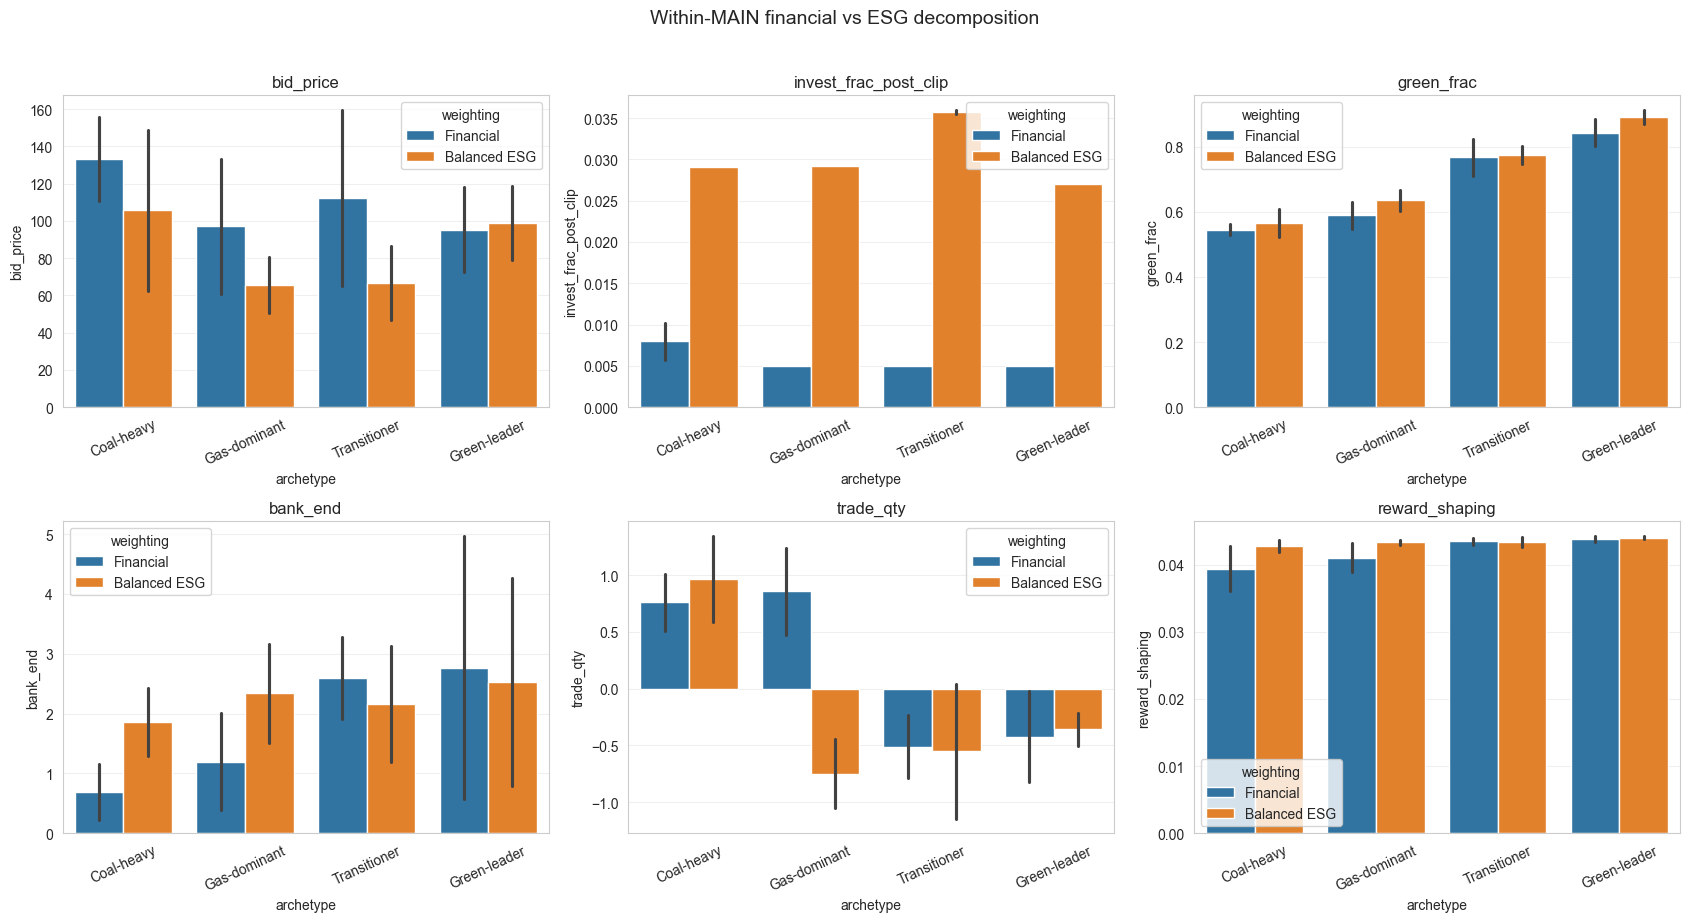

secondary_role             net buyer  net seller
archetype    weighting                          
Coal-heavy   Balanced ESG        1.0         0.0
             Financial           1.0         0.0
Gas-dominant Balanced ESG        0.0         1.0
             Financial           1.0         0.0
Green-leader Balanced ESG        0.0         1.0
             Financial           0.0         1.0
Transitioner Balanced ESG        0.0         1.0
             Financial           0.0         1.0

Reward composition proxy (reward_base is financial+ESG−penalty; ESG term is not separately logged in CSV):


,reward,reward_base,reward_shaping,penalty,invest_cost
weighting,,,,,
Balanced ESG,0.3922,0.3488,0.0434,13.6346,76.5806
Financial,0.0639,0.0220,0.0420,53.7740,45.8890


In [20]:
main_seeds = sorted({seed for (variant, seed) in runs if variant == 'MAIN'})
main_agents = agent_group_table(['MAIN'], seeds=main_seeds)
if main_agents.empty:
    print('No MAIN agent-level data available.')
else:
    metrics = ['bid_price', 'invest_frac_post_clip', 'green_frac', 'bank_end', 'trade_qty', 'sec_qty_action',
               'shortfall', 'penalty', 'reward', 'reward_base', 'reward_shaping', 'invest_cost']
    display(main_agents.groupby(['archetype', 'weighting'])[metrics].mean().round(4))
    display(main_agents.groupby('weighting')[metrics].mean().round(4))

    fig, axes = plt.subplots(2, 3, figsize=(17, 9))
    for ax, metric in zip(axes.ravel(), ['bid_price', 'invest_frac_post_clip', 'green_frac', 'bank_end', 'trade_qty', 'reward_shaping']):
        sns.barplot(data=main_agents, x='archetype', y=metric, hue='weighting', errorbar='sd', ax=ax)
        ax.set_title(metric); ax.tick_params(axis='x', rotation=25); ax.grid(True, alpha=0.3, axis='y')
    plt.suptitle('Within-MAIN financial vs ESG decomposition', fontsize=14, y=1.02)
    plt.tight_layout(); plt.show()

    # Secondary-market direction: positive trade_qty = buyer, negative = seller.
    sm = main_agents.copy()
    sm['secondary_role'] = np.select([sm['trade_qty'] > 1e-6, sm['trade_qty'] < -1e-6], ['net buyer', 'net seller'], default='neutral')
    display(pd.crosstab([sm['archetype'], sm['weighting']], sm['secondary_role'], normalize='index').round(3))

    # Reward composition proxy: direct ESG component is not logged separately, so reward_shaping + ESG diagnostics are used as evidence.
    esg_cols = [c for c in ['reward', 'reward_base', 'reward_shaping', 'penalty', 'invest_cost'] if c in main_agents.columns]
    print('Reward composition proxy (reward_base is financial+ESG−penalty; ESG term is not separately logged in CSV):')
    display(main_agents.groupby('weighting')[esg_cols].mean().round(4))

**Reward decomposition caveat.** The CSV exposes `reward`, `reward_base`, `reward_shaping`, penalties, and investment costs, but not a clean year-level `financial_term` vs `esg_term` split. Use the weighting comparison plus `esg_vs_penalty_ratio_A*` / `compliance_gate_A*` from episode logs as the diagnostic evidence, and state that the exact ESG component is inferred rather than directly observed.

### 12a. MAIN Reward Composition Proxy — Cost / ESG / Penalty

The simulator does not currently log the final `esg_signal` and full financial cost norm as separate CSV columns. This cell reconstructs the closest auditable proxy from year-level cost buckets and the documented ESG flow formula:

- **Cost proxy:** auction + secondary + MAC + investment + collateral costs.
- **Penalty:** logged penalty cost.
- **ESG flow proxy:** `(initial_ef - realised_ef) / initial_ef × (real_anchor_t / real_anchor_0)`, gated by observed compliance where possible.

Use this to verify whether ESG-weighted agents are exposed to a materially larger ESG-flow channel than financial agents, while noting the residual caveat in the thesis text.

cost_proxy   penalty  esg_flow_proxy  reward_base  reward_shaping
archetype    weighting                                                                      
Coal-heavy   Balanced ESG    341.1468   19.9979          0.2918      -0.2044          0.0428
             Financial       231.8318  130.0833          0.1316      -0.6823          0.0394
Gas-dominant Balanced ESG    358.0943   15.0288          0.3691       0.3880          0.0433
             Financial       272.3957   71.6212          0.1780      -0.8818          0.0411
Green-leader Balanced ESG    199.8938    1.3283          0.6137       0.8289          0.0441
             Financial       195.9306    4.2336          0.4218       0.8533          0.0438
Transitioner Balanced ESG    236.7987   18.1832          0.4436       0.3825          0.0434
             Financial       268.9285    9.1581          0.4293       0.7987          0.0435

,cost_proxy,penalty,esg_flow_proxy,reward_base,reward_shaping
weighting,,,,,
Balanced ESG,283.9834,13.6346,0.4295,0.3488,0.0434
Financial,242.2716,53.7740,0.2901,0.0220,0.0420


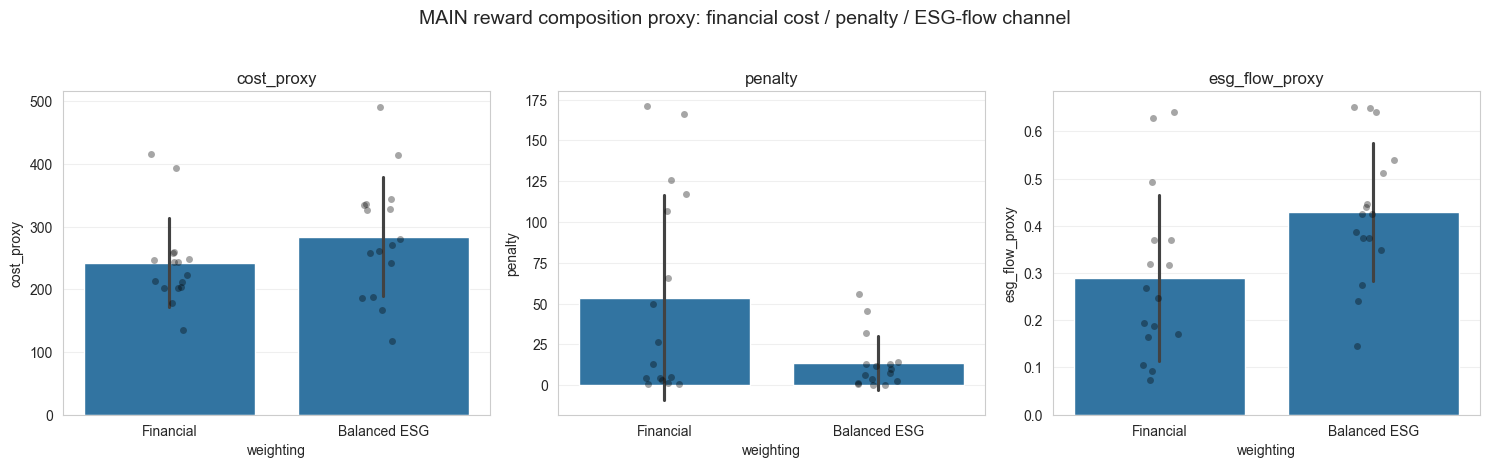

In [21]:
def _initial_ef_for_agent(run, i):
    tech = run['config'].get('technologies', {})
    efs = np.asarray(tech.get('emission_factors', []), dtype=float)
    mix = run['config'].get('companies', {}).get('initial_mix', [])
    if i >= len(mix) or len(efs) == 0:
        return np.nan
    m = np.asarray(mix[i], dtype=float)
    n = min(len(m), len(efs))
    return float(np.dot(m[:n], efs[:n]))

def _agent_reward_proxy(variants, seeds=None):
    """Reconstruct auditable reward-channel proxies from logged CSV fields.

    The true ESG signal is not directly logged separately; this function must
    remain labelled as an inferred proxy in any downstream reporting. The
    ESG-flow proxy mirrors the documented formula's flow component: avoided emission intensity
    relative to the agent's initial mix, multiplied by the real anchor ratio
    and a binary observed-compliance gate. It is therefore a directional
    diagnostic, not a replacement for the simulator's internal reward term.
    """
    rows = []
    for (variant, seed), run in runs.items():
        if variant not in variants or (seeds is not None and seed not in seeds):
            continue
        yr = _tail_yr(run)
        if yr.empty:
            continue
        output_twh = float(run['config'].get('companies', {}).get('output_twh', 10.0))
        if 'fundamental_anchor' in yr.columns and 'inflation_factor' in yr.columns:
            infl = yr['inflation_factor'].replace(0, np.nan)
            anchor_real = yr['fundamental_anchor'] / infl
            anchor0 = anchor_real[yr['year'].eq(0)].dropna()
            # Tail windows contain many episodes; use the median year-0 real
            # anchor rather than silently selecting the first episode.
            anchor0 = float(anchor0.median()) if len(anchor0) else np.nan
            anchor_ratio = anchor_real / max(anchor0, 1.0)
        else:
            anchor_ratio = pd.Series(1.0, index=yr.index)
        for i in range(N_AGENTS):
            init_ef = _initial_ef_for_agent(run, i)
            emissions_col = f'emissions_A{i+1}'
            short_col = f'shortfall_A{i+1}'
            if emissions_col in yr.columns and np.isfinite(init_ef) and init_ef > 0:
                realised_ef = yr[emissions_col] / max(output_twh, EPS)
                ef_ratio = ((init_ef - realised_ef) / init_ef).clip(lower=0)
            else:
                ef_ratio = pd.Series(np.nan, index=yr.index)
            if short_col in yr.columns:
                compliance_gate_proxy = (yr[short_col] <= 1e-6).astype(float)
            else:
                compliance_gate_proxy = 1.0
            # Proxy only: direct esg_signal/esg_flow_term is not persisted in
            # year_log, so this reconstructs direction/magnitude from available
            # emissions, anchor, and compliance-gate observables.
            esg_flow_proxy = ef_ratio * anchor_ratio * compliance_gate_proxy
            cost_parts = []
            for prefix in ['auction_cost', 'secondary_net', 'mac_cost', 'invest_cost', 'collateral_cost']:
                col = f'{prefix}_A{i+1}'
                if col in yr.columns:
                    cost_parts.append(yr[col].abs() if prefix == 'secondary_net' else yr[col])
            cost_proxy = sum(cost_parts) if cost_parts else pd.Series(np.nan, index=yr.index)
            pen_col = f'penalty_A{i+1}'
            rows.append({
                'variant': variant, 'seed': seed, 'agent': f'A{i+1}', 'archetype': _agent_archetype(i),
                'weighting': _agent_weighting(run, i),
                'cost_proxy': _safe_mean(cost_proxy),
                'penalty': _safe_mean(yr[pen_col]) if pen_col in yr.columns else np.nan,
                'esg_flow_proxy': _safe_mean(esg_flow_proxy),
                'reward_base': _safe_mean(yr[f'reward_base_A{i+1}']) if f'reward_base_A{i+1}' in yr.columns else np.nan,
                'reward_shaping': _safe_mean(yr[f'reward_shaping_A{i+1}']) if f'reward_shaping_A{i+1}' in yr.columns else np.nan,
            })
    return pd.DataFrame(rows)

main_reward_proxy = _agent_reward_proxy(['MAIN'])
if main_reward_proxy.empty:
    print('No MAIN reward-proxy data available.')
else:
    display(main_reward_proxy.groupby(['archetype', 'weighting'])[['cost_proxy', 'penalty', 'esg_flow_proxy', 'reward_base', 'reward_shaping']].mean().round(4))
    display(main_reward_proxy.groupby('weighting')[['cost_proxy', 'penalty', 'esg_flow_proxy', 'reward_base', 'reward_shaping']].mean().round(4))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, metric in zip(axes, ['cost_proxy', 'penalty', 'esg_flow_proxy']):
        sns.barplot(data=main_reward_proxy, x='weighting', y=metric, errorbar='sd', ax=ax)
        sns.stripplot(data=main_reward_proxy, x='weighting', y=metric, color='black', alpha=0.35, ax=ax)
        ax.set_title(metric); ax.grid(True, alpha=0.3, axis='y')
    plt.suptitle('MAIN reward composition proxy: financial cost / penalty / ESG-flow channel', fontsize=14, y=1.03)
    plt.tight_layout(); plt.show()

## 13. High-Inflation Single-Seed Probe

C:\Users\danie\AppData\Local\Temp\ipykernel_28284\2486335180.py:39: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


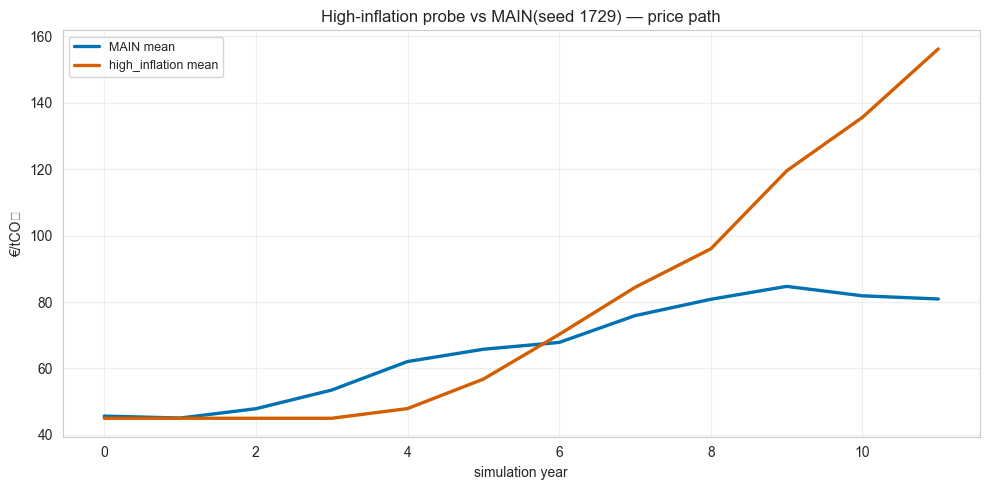

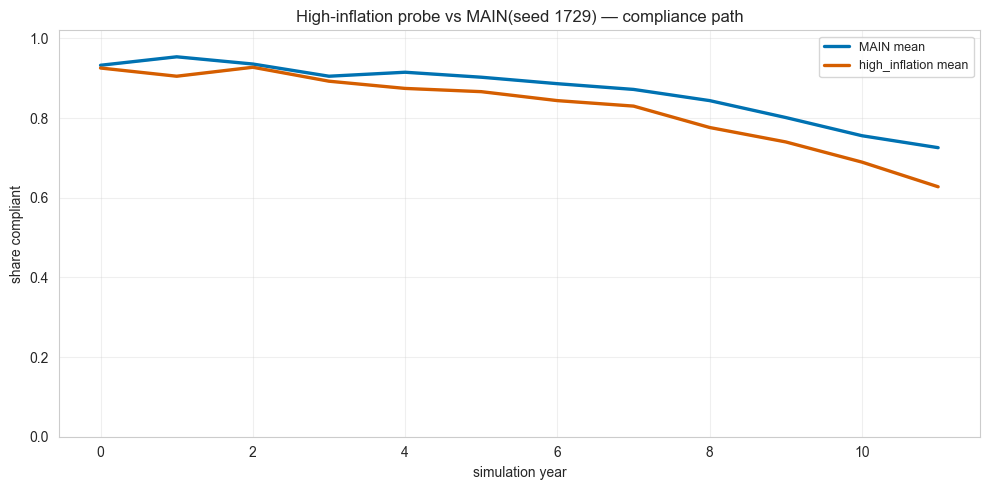

,variant,seed,mean_price,green_pct_year12,compliance_rate,penalty_frequency,penalty_magnitude_positive,budget_gate_clip_freq,quality_score,Q_volatility,within_episode_price_std,system_reward
0,MAIN,1729,66.002251,73.370737,0.869062,0.130938,156.334717,0.0,1.664640,0.265321,24.101362,20.853182
19,high_inflation,1729,78.897438,77.521002,0.824844,0.175156,214.555756,0.0,1.338805,0.355136,45.977570,4.702674


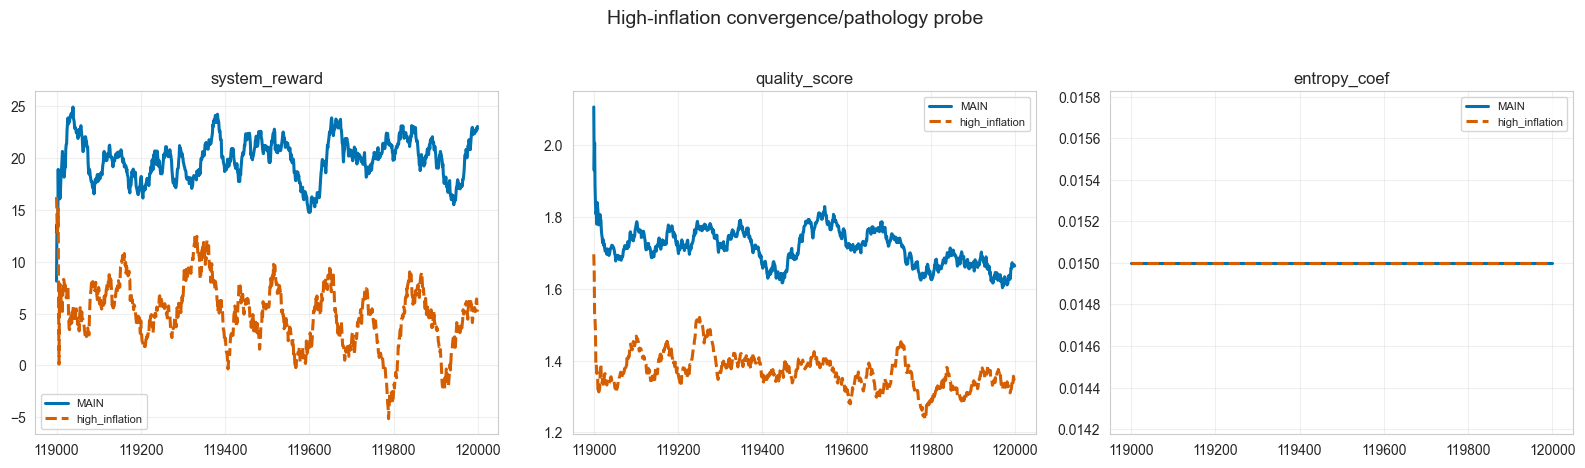

Decision: YES — warrants a full 3-seed run.
Justification: compliance drop=0.044, quality drop=0.326, budget-gate clip jump=0.000.


In [23]:
# Colorblind-safe palette (Okabe-Ito) + style redundancy (linestyle)
VARIANT_COLOR.update({
    'MAIN': '#0072B2',            # blue
    'high_inflation': '#D55E00',  # vermillion
})
variant_style = {
    'MAIN': '-',
    'high_inflation': '--',
}

_plot_yearly_variants(
    ['MAIN', 'high_inflation'],
    price_metric,
    'High-inflation probe vs MAIN(seed 1729) — price path',
    '€/tCO₂',
    seeds=[1729],
)
_plot_yearly_variants(
    ['MAIN', 'high_inflation'],
    compliance_metric,
    'High-inflation probe vs MAIN(seed 1729) — compliance path',
    'share compliant',
    seeds=[1729],
    ylim=(0, 1.02),
)

hi_cols = ['variant', 'seed', 'mean_price', 'green_pct_year12', 'compliance_rate', 'penalty_frequency',
           'penalty_magnitude_positive', 'budget_gate_clip_freq', 'quality_score', 'Q_volatility',
           'within_episode_price_std', 'system_reward']
hi_df = summary_df[
    summary_df['variant'].astype(str).isin(['MAIN', 'high_inflation']) & summary_df['seed'].eq(1729)
][hi_cols]
display(hi_df)

# Episode-level diagnostics for the single seed.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric in zip(axes, ['system_reward', 'quality_score', 'entropy_coef']):
    for variant in ['MAIN', 'high_inflation']:
        run = runs.get((variant, 1729))
        if run is None or run['ep_df'].empty:
            continue
        ep = run['ep_df']
        if metric == 'system_reward':
            cols = agent_cols(ep, 'reward')
            s = ep[cols].sum(axis=1) if cols else pd.Series(dtype=float)
        elif metric in ep.columns:
            s = ep[metric]
        else:
            continue
        x = ep['episode'] if 'episode' in ep.columns else np.arange(len(ep))
        ax.plot(
            x,
            s.rolling(ROLL, min_periods=1).mean(),
            label=variant,
            color=VARIANT_COLOR.get(variant),
            linestyle=variant_style.get(variant, '-'),
            linewidth=2.2
        )
    ax.set_title(metric)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
plt.suptitle('High-inflation convergence/pathology probe', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

if not hi_df.empty and {'compliance_rate', 'quality_score', 'budget_gate_clip_freq'}.issubset(hi_df.columns):
    main = hi_df[hi_df['variant'].astype(str) == 'MAIN']
    high = hi_df[hi_df['variant'].astype(str) == 'high_inflation']
    if len(main) and len(high):
        comp_drop = float(main['compliance_rate'].iloc[0] - high['compliance_rate'].iloc[0])
        q_drop = float(main['quality_score'].iloc[0] - high['quality_score'].iloc[0])
        gate_jump = (
            float(high['budget_gate_clip_freq'].iloc[0] - main['budget_gate_clip_freq'].iloc[0])
            if pd.notna(high['budget_gate_clip_freq'].iloc[0]) and pd.notna(main['budget_gate_clip_freq'].iloc[0])
            else np.nan
        )
        promote = (comp_drop > 0.05) or (q_drop > 0.10) or (pd.notna(gate_jump) and gate_jump > 0.05)
        print('Decision:', 'YES — warrants a full 3-seed run.' if promote else 'NO — single-seed probe does not show a large qualitative break.')
        print(f'Justification: compliance drop={comp_drop:.3f}, quality drop={q_drop:.3f}, budget-gate clip jump={gate_jump:.3f}.')

### 13a. High-Inflation ESG Flow-Term Magnitude

This probe uses the same ESG-flow proxy as §12a to check whether rising real anchors make the ESG flow channel explode under the high-inflation single seed.

cost_proxy  penalty  esg_flow_proxy  reward_base  reward_shaping
variant        weighting                                                                     
MAIN           Balanced ESG    355.4207   5.9697          0.4468       0.4622          0.0433
               Financial       272.4096  34.9705          0.2632      -0.1132          0.0421
high_inflation Balanced ESG    404.2931  11.4727          0.3862       0.2207          0.0498
               Financial       359.6050  63.6888          0.2889      -0.2193          0.0468

C:\Users\danie\AppData\Local\Temp\ipykernel_28284\930182696.py:8: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=hi_reward_proxy, x='variant', y='esg_flow_proxy', hue='weighting', dodge=True,


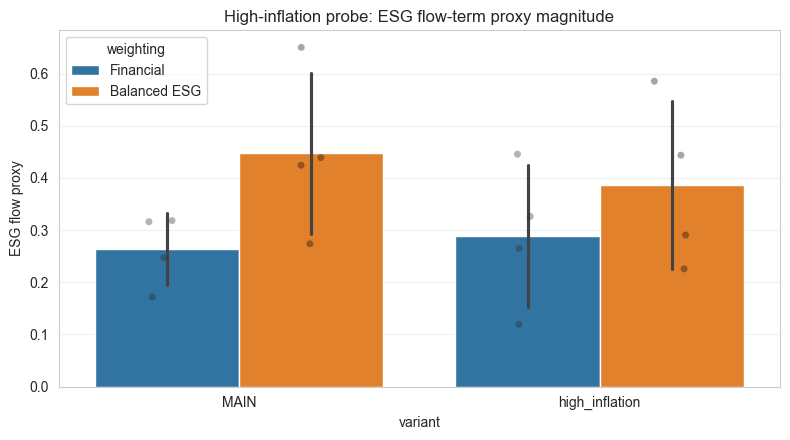

ESG-flow proxy ratio high_inflation / MAIN (seed 1729): 0.95×


In [24]:
hi_reward_proxy = _agent_reward_proxy(['MAIN', 'high_inflation'], seeds=[1729])
if hi_reward_proxy.empty:
    print('No high-inflation reward-proxy data available.')
else:
    display(hi_reward_proxy.groupby(['variant', 'weighting'])[['cost_proxy', 'penalty', 'esg_flow_proxy', 'reward_base', 'reward_shaping']].mean().round(4))
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.barplot(data=hi_reward_proxy, x='variant', y='esg_flow_proxy', hue='weighting', errorbar='sd', ax=ax)
    sns.stripplot(data=hi_reward_proxy, x='variant', y='esg_flow_proxy', hue='weighting', dodge=True,
                  color='black', alpha=0.35, legend=False, ax=ax)
    ax.set_title('High-inflation probe: ESG flow-term proxy magnitude')
    ax.set_ylabel('ESG flow proxy')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout(); plt.show()

    piv = hi_reward_proxy.groupby('variant')['esg_flow_proxy'].mean()
    if {'MAIN', 'high_inflation'}.issubset(set(piv.index)):
        main_esg_flow = float(piv['MAIN'])
        ratio = float(piv['high_inflation']) / (main_esg_flow if main_esg_flow > EPS else EPS)
        print(f'ESG-flow proxy ratio high_inflation / MAIN (seed 1729): {ratio:.2f}×')
        if ratio > 2.0:
            print('FLAG: ESG-flow proxy more than doubles; inspect whether real-anchor scaling is dominating rewards.')

## 14. Headline Figures

C:\Users\danie\AppData\Local\Temp\ipykernel_28284\1333089454.py:46: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\danie\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


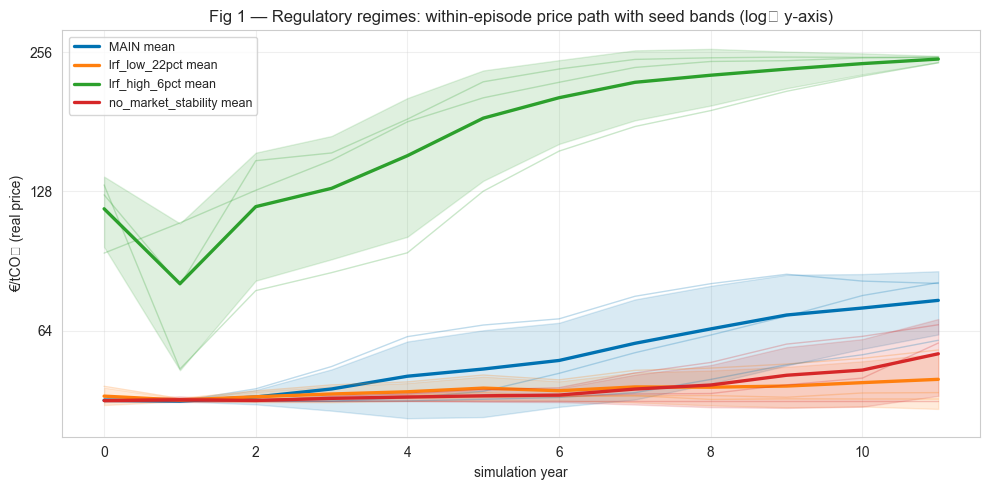

In [30]:
# Fig 1: within-episode price path, all 4 regulatory regimes, with log2 y-scale.
import matplotlib.ticker as mticker

fig1_variants = ['MAIN', 'lrf_low_22pct', 'lrf_high_6pct', 'no_market_stability']
fig1_df = pd.concat(
    [_yearly_metric(v, price_metric, seeds=PAIRED_SEEDS) for v in fig1_variants],
    ignore_index=True
)

fig, ax = plt.subplots(figsize=(10, 5))
if fig1_df.empty:
    ax.text(0.5, 0.5, 'No year-level data', ha='center', va='center', transform=ax.transAxes)
else:
    for variant in fig1_variants:
        sub = fig1_df[fig1_df['variant'] == variant]
        if sub.empty:
            continue
        by = sub.groupby(['seed', 'year'])['value'].mean().reset_index()

        for seed, g in by.groupby('seed'):
            ax.plot(g['year'], g['value'], color=VARIANT_COLOR.get(variant), alpha=0.25, lw=1)

        agg = by.groupby('year')['value'].agg(['mean', 'std']).reset_index()
        ax.plot(agg['year'], agg['mean'], color=VARIANT_COLOR.get(variant), lw=2.4, label=f'{variant} mean')
        ax.fill_between(
            agg['year'],
            (agg['mean'] - agg['std'].fillna(0)).clip(lower=EPS),
            agg['mean'] + agg['std'].fillna(0),
            color=VARIANT_COLOR.get(variant),
            alpha=0.15
        )

# log base 2, but tick labels show real prices (not 2^k notation)
ax.set_yscale('log', base=2)
ax.yaxis.set_major_locator(mticker.LogLocator(base=2))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.0f}'))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.set(
    title='Fig 1 — Regulatory regimes: within-episode price path with seed bands (log₂ y-axis)',
    xlabel='simulation year',
    ylabel='€/tCO₂ (real price)'
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\danie\AppData\Local\Temp\ipykernel_28284\460732173.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='variant', y=metric, order=[v for v in VARIANT_ORDER if v in set(df['variant'].astype(str))],
C:\Users\danie\AppData\Local\Temp\ipykernel_28284\460732173.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='variant', y=metric, order=[v for v in VARIANT_ORDER if v in set(df['variant'].astype(str))],
C:\Users\danie\AppData\Local\Temp\ipykernel_28284\460732173.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplo

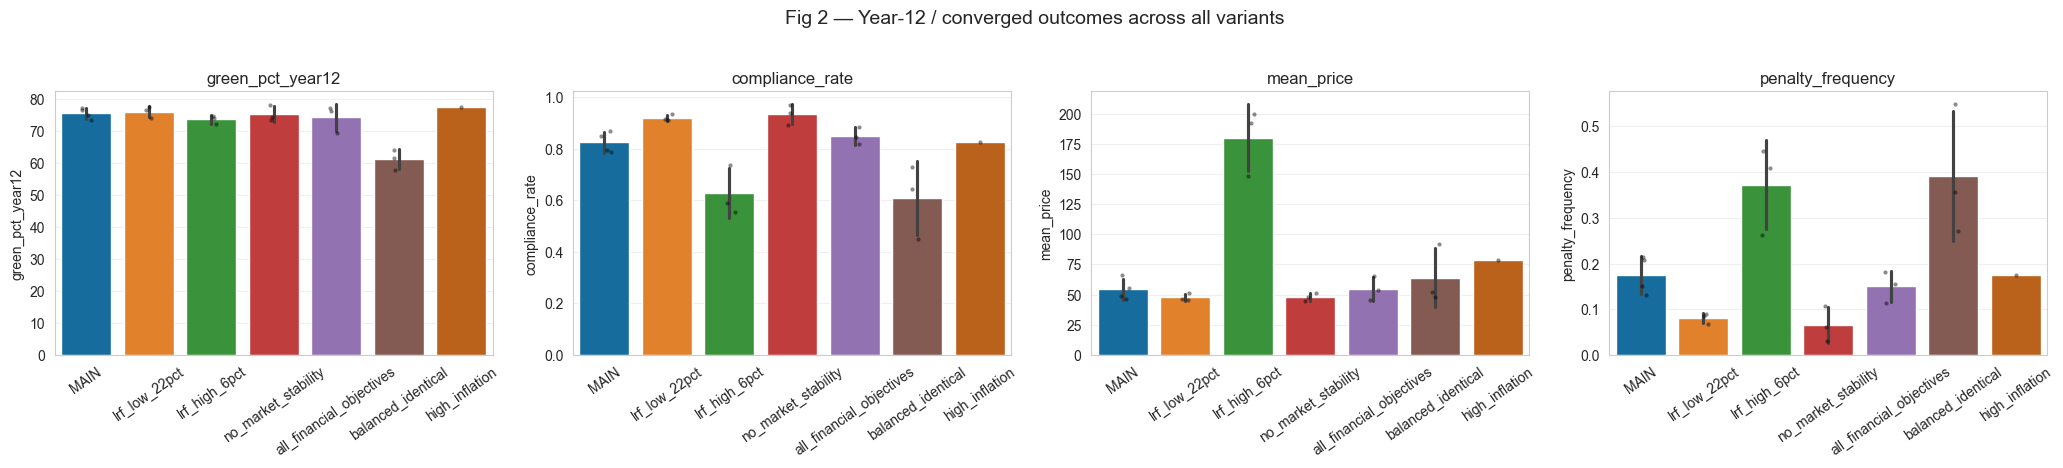

In [31]:
# Fig 2: year-12 outcomes bar chart, all variants.
fig2_metrics = ['green_pct_year12', 'compliance_rate', 'mean_price', 'penalty_frequency']
plot_variant_bars(fig2_metrics, 'Fig 2 — Year-12 / converged outcomes across all variants', paired_only=False)

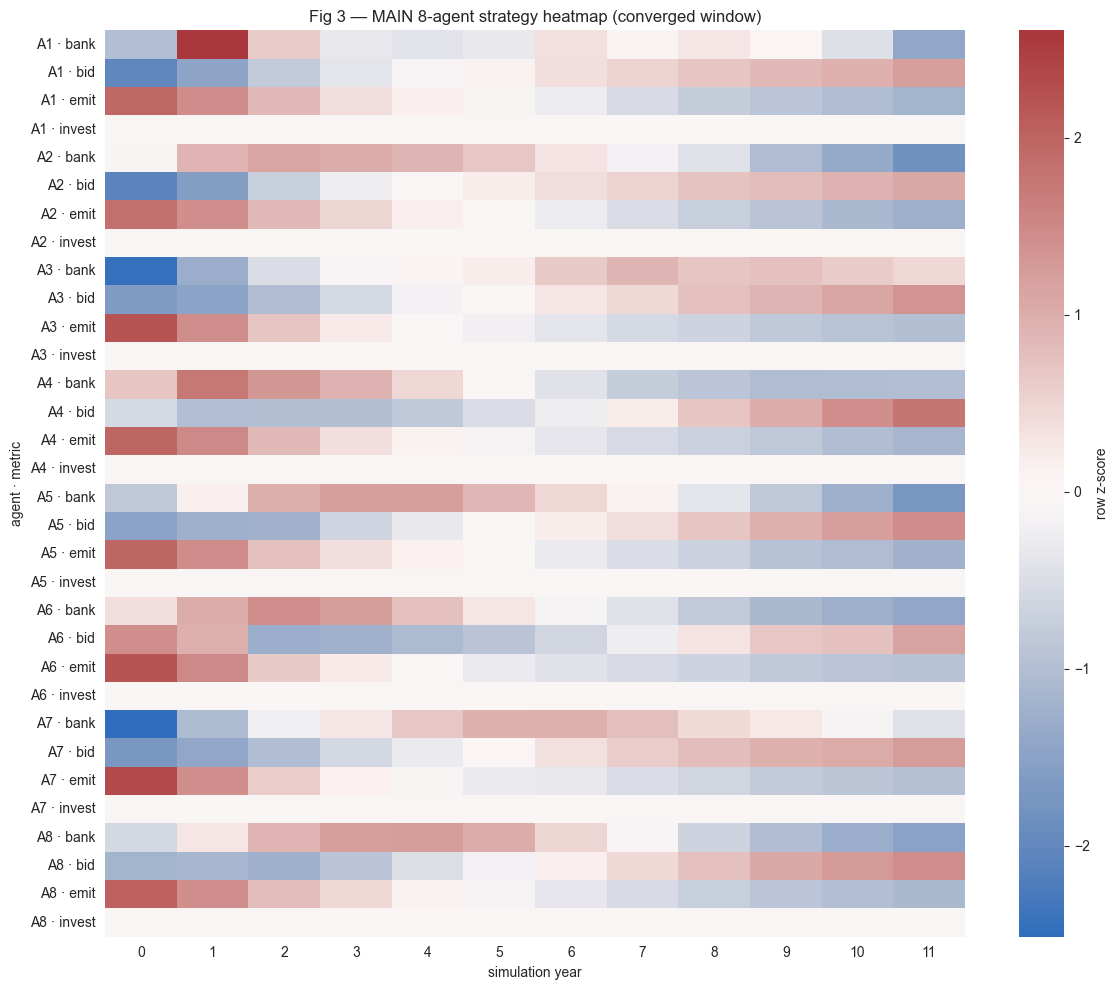

In [32]:
# Fig 3: 8-agent strategy heatmap for MAIN converged window (bid, invest, bank, emit × year).
def main_strategy_heatmap(seed=None):
    main_keys = sorted([k for k in runs if k[0] == 'MAIN'])
    if seed is not None:
        main_keys = [k for k in main_keys if k[1] == seed]
    if not main_keys:
        print('No MAIN runs loaded.')
        return
    rows = []
    for k in main_keys:
        run = runs[k]
        yr = _tail_yr(run)
        if yr.empty:
            continue
        for i in range(N_AGENTS):
            for metric, prefix in [('bid', 'bid_price'), ('invest', 'invest_frac_post_clip'), ('bank', 'bank_end'), ('emit', 'emissions')]:
                col = f'{prefix}_A{i+1}'
                if col not in yr.columns:
                    continue
                s = yr.groupby('year')[col].mean()
                for year, value in s.items():
                    rows.append({'seed': k[1], 'agent': f'A{i+1}', 'metric': metric, 'year': year, 'value': value})
    df = pd.DataFrame(rows)
    if df.empty:
        print('No strategy heatmap data available.')
        return
    df = df.groupby(['agent', 'metric', 'year'])['value'].mean().reset_index()
    df['row'] = df['agent'] + ' · ' + df['metric']
    mat = df.pivot(index='row', columns='year', values='value')
    # Row-standardize so bid/invest/bank/emissions can share one heatmap.
    mat_z = mat.sub(mat.mean(axis=1), axis=0).div(mat.std(axis=1).replace(0, np.nan), axis=0).fillna(0)
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(mat_z, cmap='vlag', center=0, ax=ax, cbar_kws={'label': 'row z-score'})
    ax.set_title('Fig 3 — MAIN 8-agent strategy heatmap (converged window)')
    ax.set_xlabel('simulation year'); ax.set_ylabel('agent · metric')
    plt.tight_layout(); plt.show()

main_strategy_heatmap()

C:\Users\danie\AppData\Local\Temp\ipykernel_28284\1364028478.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=market, x='variant', y='green_pct_year12', errorbar='sd', order=['MAIN', 'all_financial_objectives', 'balanced_identical'], ax=axes[2], palette=VARIANT_COLOR)


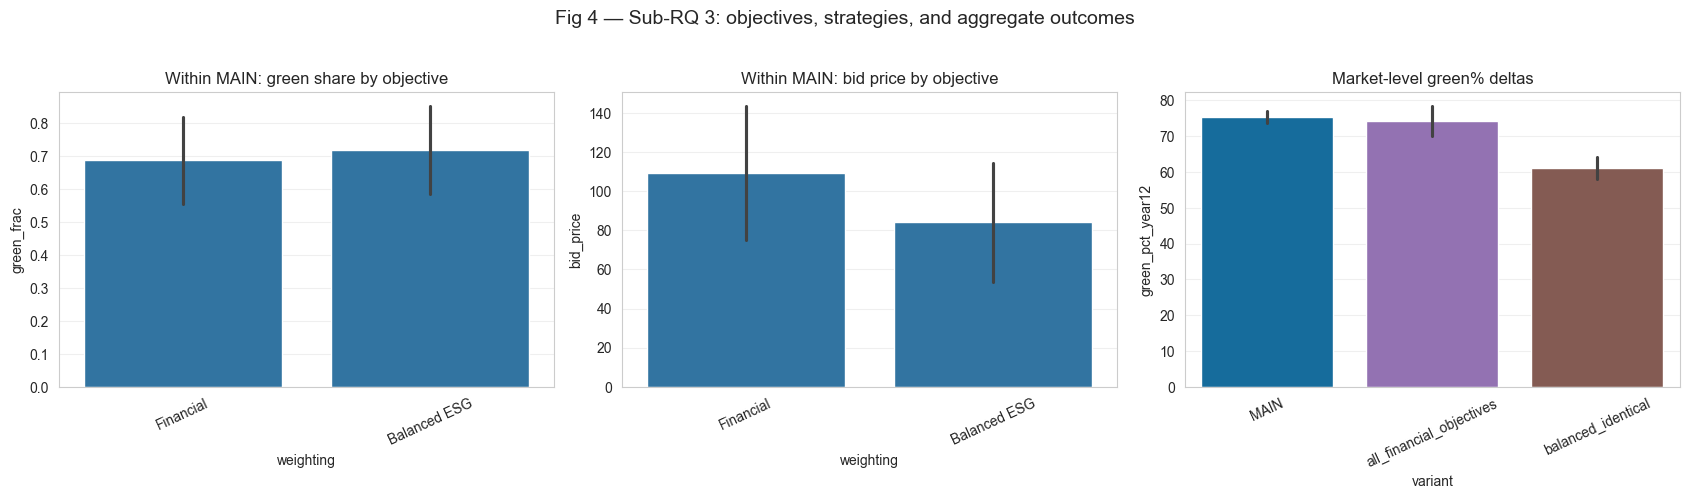

In [33]:
# Fig 4: Sub-RQ 3 panel — fin vs ESG within MAIN + MAIN/all-fin/balanced market-level deltas.
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
if not main_agents.empty:
    sns.barplot(data=main_agents, x='weighting', y='green_frac', errorbar='sd', ax=axes[0])
    axes[0].set_title('Within MAIN: green share by objective')
    sns.barplot(data=main_agents, x='weighting', y='bid_price', errorbar='sd', ax=axes[1])
    axes[1].set_title('Within MAIN: bid price by objective')
else:
    axes[0].text(0.5, 0.5, 'No MAIN agent data', ha='center', va='center', transform=axes[0].transAxes)
    axes[1].text(0.5, 0.5, 'No MAIN agent data', ha='center', va='center', transform=axes[1].transAxes)
market = summary_df[summary_df['variant'].astype(str).isin(['MAIN', 'all_financial_objectives', 'balanced_identical'])]
sns.barplot(data=market, x='variant', y='green_pct_year12', errorbar='sd', order=['MAIN', 'all_financial_objectives', 'balanced_identical'], ax=axes[2], palette=VARIANT_COLOR)
axes[2].set_title('Market-level green% deltas')
for ax in axes:
    ax.tick_params(axis='x', rotation=25); ax.grid(True, alpha=0.3, axis='y')
plt.suptitle('Fig 4 — Sub-RQ 3: objectives, strategies, and aggregate outcomes', fontsize=14, y=1.03)
plt.tight_layout(); plt.show()

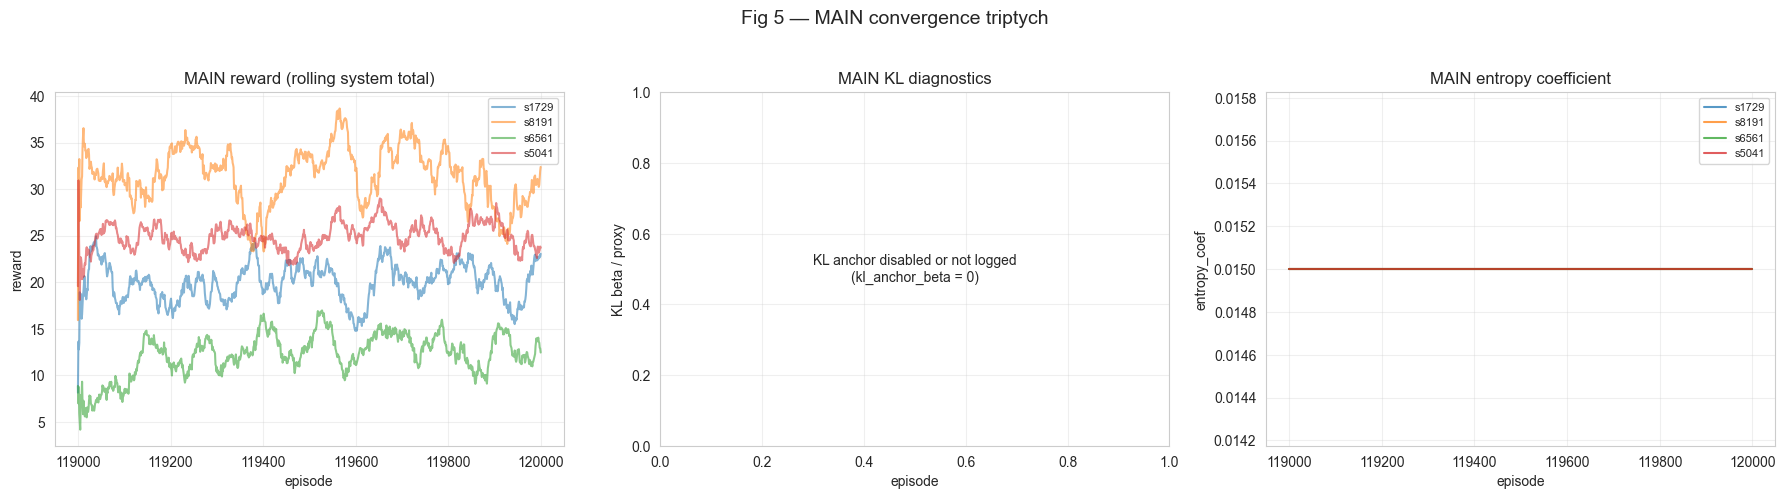

In [34]:
# Fig 5: convergence triptych for MAIN (reward, KL schedule/proxy, entropy).
main_runs = {k: v for k, v in runs.items() if k[0] == 'MAIN'}
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

for (variant, seed), run in main_runs.items():
    ep = run['ep_df']
    if ep.empty:
        continue
    x = ep['episode'] if 'episode' in ep.columns else np.arange(len(ep))
    rew_cols = agent_cols(ep, 'reward')
    if rew_cols:
        axes[0].plot(x, ep[rew_cols].sum(axis=1).rolling(ROLL, min_periods=1).mean(), alpha=0.55, label=f's{seed}')
    if 'entropy_coef' in ep.columns:
        axes[2].plot(x, ep['entropy_coef'], alpha=0.75, label=f's{seed}')
axes[0].set_title('MAIN reward (rolling system total)'); axes[0].set_xlabel('episode'); axes[0].set_ylabel('reward')

# KL beta is not written to training_log; reconstruct schedule from config if enabled.
if main_runs:
    ref_run = next(iter(main_runs.values()))
    cfg = ref_run['config']
    ep_len = max((r.get('n_total_episodes', len(r['ep_df'])) for r in main_runs.values()), default=0)
    beta0 = float(cfg.get('ppo', {}).get('kl_anchor_beta', 0.0))
    n_eps = int(cfg.get('simulation', {}).get('n_episodes', ep_len or 1))
    decay_raw = int(cfg.get('ppo', {}).get('kl_anchor_decay_episodes', 0) or 0)
    decay = decay_raw if decay_raw > 0 else int(0.50 * n_eps)
    xs = np.arange(ep_len)
    if beta0 > 0 and ep_len > 0:
        beta = beta0 * np.maximum(0, 1 - xs / max(decay, 1))
        axes[1].plot(xs, beta, color='purple', lw=2)
        axes[1].set_title('MAIN KL-anchor beta schedule (reconstructed)')
    else:
        axes[1].text(0.5, 0.5, 'KL anchor disabled or not logged\n(kl_anchor_beta = 0)', ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title('MAIN KL diagnostics')
axes[1].set_xlabel('episode'); axes[1].set_ylabel('KL beta / proxy')
axes[2].set_title('MAIN entropy coefficient'); axes[2].set_xlabel('episode'); axes[2].set_ylabel('entropy_coef')
for ax in axes:
    ax.grid(True, alpha=0.3)
    if ax.get_legend_handles_labels()[0]:
        ax.legend(fontsize=8)
plt.suptitle('Fig 5 — MAIN convergence triptych', fontsize=14, y=1.03)
plt.tight_layout(); plt.show()

## 15. Research-Question Synthesis

Use this final section after reviewing the generated tables/figures.

### RQ1 — Simulation credibility

Evidence to cite:

- MAIN convergence triptych (Fig 5): reward trajectory, entropy schedule, and KL-anchor status.
- Cross-seed bands in Fig 1 and summary-table standard deviations: whether seed noise is smaller than cross-variant differences.
- `quality_score`, `Q_compliance`, and `Q_volatility` in the overview table.

Suggested claim format:

> The model is credible for sensitivity analysis if MAIN shows stable converged-window reward/quality, high compliance, bounded price volatility, and cross-seed variation smaller than the lrf/MSR/objective variant deltas.

### RQ2 — Regulatory-mechanism sensitivity

Evidence to cite:

- **LRF low vs MAIN:** floor-touch frequency, low-TNAC scarcity timing, price path, and lower/higher green investment timing.
- **LRF high vs MAIN:** ceiling-touch frequency, earlier scarcity, carry-forward/penalty stress, and green investment pull-forward.
- **Cross-LRF elasticity:** `Δgreen% / Δpp LRF` table quantifies decarbonization responsiveness.
- **MSR-off:** if MAIN has zero MSR events, explicitly state the comparison is null for MSR mechanics; otherwise use TNAC, unsold volume, banking, and price variance to evaluate the stabilizer.

Suggested claim format:

> Regulatory levers matter if LRF/MSR variants move both aggregate outcomes (price, compliance, green%) and mechanisms (TNAC, banking, unsold volume, carry-forward), not merely the headline price.

### RQ3 — Strategic behaviour and aggregation

Evidence to cite:

- **MAIN decomposition:** financial vs ESG agents on bidding, investment, banking, secondary-market direction, and reward proxies.
- **all_financial_objectives:** whether removing ESG collapses strategy diversity or whether carbon-cost NPV still drives green investment.
- **balanced_identical:** whether identical endowments still diverge by reward objective; this isolates preference from initial asset mix.
- **Fig 3 heatmap:** year-by-year agent strategy structure in the converged MAIN market.

Suggested claim format:

> Objective weights shape strategy if ESG agents differ systematically from financial agents inside MAIN and if the all-financial / balanced-identical counterfactuals alter the spread of bids, investments, banks, and secondary-market roles.

### High-inflation probe decision

Use the automated single-seed decision line as a screening rule, then add qualitative judgment from the price/compliance/convergence plots. A full 3-seed run is warranted only if the high-inflation seed shows a clear compliance, budget-gate, volatility, or convergence break relative to MAIN seed 1729.